In [504]:
print("I am becoming a Data Scientist")

I am becoming a Data Scientist


In [505]:
import pandas as pd

In [506]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [507]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [508]:
df.shape

(7043, 21)

In [509]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [510]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [511]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [512]:
# Inspect the first 20 values in the TotalCharges column
# We are doing this to understand why Pandas classified it as an "object"
df["TotalCharges"].head(20)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [513]:
# Find values in TotalCharges that cannot be converted to numbers
# We use this to identify unusual or invalid entries in the column

pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [514]:
# Identify the rows where TotalCharges cannot be converted to a number
# We want to inspect the problematic values before deciding how to handle them

invalid_total_charges = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).isna()

df.loc[invalid_total_charges, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [515]:
# Check the minimum customer tenure
# We are verifying whether the customers with missing TotalCharges
# are actually new customers with zero months of tenure

df["tenure"].min()

0

In [516]:
# Count customers whose tenure is zero
# This helps us understand how common this situation is in the dataset

(df["tenure"] == 0).sum()

np.int64(11)

In [517]:
# Check whether every customer with zero tenure also has a blank TotalCharges value
# This confirms whether the missing charges are consistently associated with new customers

zero_tenure = df["tenure"] == 0
blank_total_charges = df["TotalCharges"].str.strip() == ""

(zero_tenure == blank_total_charges).all()

np.True_

In [518]:
# Convert TotalCharges from text to numeric values
# Invalid or blank values are temporarily converted to NaN (missing values)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [519]:
# Replace the 11 missing TotalCharges values with 0
# These customers have zero tenure, so they have no accumulated charges

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [520]:
# Confirm that TotalCharges is now stored as a numeric column

df["TotalCharges"].dtype

dtype('float64')

In [521]:
# Check that the dataset still contains the same number of rows
# We want to make sure our cleaning process did not accidentally remove customers

df.shape

(7043, 21)

In [522]:
# Check how many missing values exist in each column
# We are doing this to identify any remaining data-quality problems
# before we begin exploratory analysis

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [523]:
# Check for duplicate customer IDs
# Each customer should have one unique record in our dataset

df["customerID"].duplicated().sum()

np.int64(0)

In [524]:
# Count how many customers churned and how many stayed
# This helps us understand the distribution of our target variable

df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [525]:
# Calculate the percentage of customers who churned
# This gives us the overall churn rate for the company

churn_rate = (df["Churn"] == "Yes").mean() * 100

churn_rate

np.float64(26.536987079369588)

In [526]:
# Import Matplotlib for data visualization
# We will use it to create charts that help us understand customer churn

import matplotlib.pyplot as plt

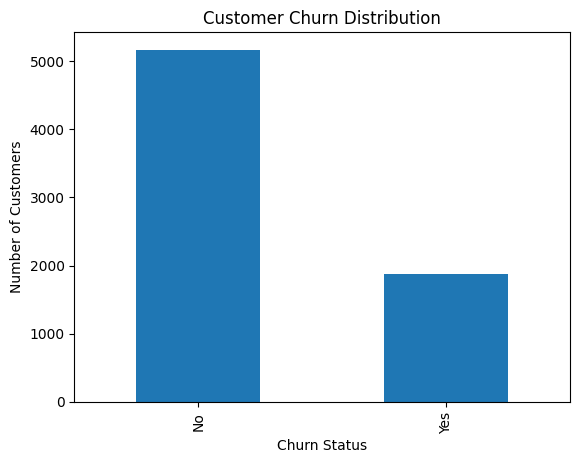

In [527]:
# Create a simple bar chart showing customers who stayed versus customers who churned
# This helps us visually compare the two groups

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [528]:
# Count customers by contract type and churn status
# This helps us understand how churn is distributed across different contracts

pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [529]:
# Calculate the percentage of customers who churned within each contract type
# This allows us to compare churn fairly between contract groups

contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


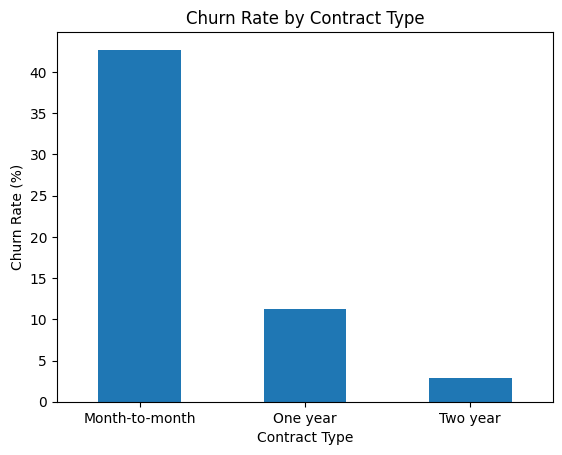

In [530]:
# Visualize churn rates by contract type
# This helps us clearly compare the proportion of customers who churn
# within each contract category

contract_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [531]:
# Examine the basic statistics of customer tenure
# This helps us understand how long customers have been with the company

df["tenure"].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [532]:
# Compare average tenure between customers who stayed and customers who churned
# This helps us determine whether customer longevity is associated with churn

df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


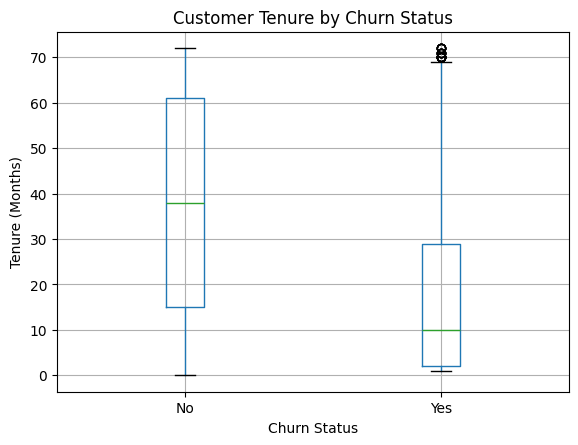

In [533]:
# Compare the distribution of customer tenure between customers who stayed and churned
# This helps us see how tenure is distributed across the two customer groups

df.boxplot(column="tenure", by="Churn")

plt.title("Customer Tenure by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.show()

In [534]:
# Compare the average customer tenure across contract types
# This helps us determine whether contract type is associated with customer longevity

df.groupby("Contract")["tenure"].mean().sort_values()

,tenure
Contract,
Month-to-month,18.036645
One year,42.044807
Two year,56.735103


In [535]:
# Compare average monthly charges between customers who stayed and customers who churned
# This helps us determine whether monthly spending is associated with churn

df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


In [536]:
# Compare average monthly charges across contract types
# We want to see whether pricing differs between contract groups,
# which may help explain some of the churn differences we observed

df.groupby("Contract")["MonthlyCharges"].mean().sort_values()

,MonthlyCharges
Contract,
Two year,60.770413
One year,65.048608
Month-to-month,66.398490


In [537]:
# Compare churn counts across different internet service types
# This helps us investigate whether internet service is associated with customer churn

pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [538]:
# Calculate the percentage of customers who churned within each internet service type
# This allows us to make a fair comparison between the different internet service groups

internet_churn_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn_rate

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [539]:
# Compare average monthly charges across internet service types
# We are checking whether pricing could help explain the higher churn rate
# observed among fiber-optic customers

df.groupby("InternetService")["MonthlyCharges"].mean().sort_values()

,MonthlyCharges
InternetService,
No,21.079194
DSL,58.102169
Fiber optic,91.500129


In [540]:
 # Examine the relationship between contract type and internet service
# This helps us understand how these two customer characteristics are distributed together

pd.crosstab(
    df["Contract"],
    df["InternetService"]
)

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,1223,2128,524
One year,570,539,364
Two year,628,429,638


In [541]:
# Calculate churn rates for each combination of contract type and internet service
# This allows us to investigate whether internet service is associated with churn
# even when customers have the same contract type

contract_internet_churn = pd.crosstab(
    [df["Contract"], df["InternetService"]],
    df["Churn"],
    normalize="index"
) * 100

contract_internet_churn

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699

In [542]:
# Examine churn rates by technical support status
# We want to investigate whether access to technical support
# is associated with customer churn

tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

tech_support_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [543]:
# Examine the relationship between internet service and technical support
# We want to see whether certain internet-service customers are more likely
# to have or not have technical support

pd.crosstab(
    df["InternetService"],
    df["TechSupport"]
)

TechSupport,No,No internet service,Yes
InternetService,,,
DSL,1243,0,1178
Fiber optic,2230,0,866
No,0,1526,0


In [544]:
# Compare churn rates among fiber-optic customers based on technical support
# We are isolating fiber customers to see whether technical support
# is associated with different churn outcomes within this group

fiber_customers = df[df["InternetService"] == "Fiber optic"]

fiber_support_churn = pd.crosstab(
    fiber_customers["TechSupport"],
    fiber_customers["Churn"],
    normalize="index"
) * 100

fiber_support_churn

Churn,No,Yes
TechSupport,,
No,50.627803,49.372197
Yes,77.367206,22.632794


In [545]:
# Compare the number of customers who stayed and churned by gender
# We start with raw counts so we can understand the size of each group

pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [546]:
# Calculate the percentage of customers who churned within each gender
# We use percentages instead of raw counts so we can fairly compare the two groups

gender_churn_rate = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

gender_churn_rate

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [547]:
# Count customers by senior-citizen status and churn outcome
# We first inspect the size of each group before calculating churn rates

pd.crosstab(df["SeniorCitizen"], df["Churn"])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


In [548]:
# Calculate the percentage of customers who churned within each senior-citizen group
# We use percentages because the two groups have very different numbers of customers

senior_churn_rate = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn_rate

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [549]:
# Compare churn outcomes based on whether a customer has a partner
# We want to investigate whether relationship status is associated with churn

partner_churn_rate = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn_rate

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [550]:
# Calculate the percentage of customers who churned based on whether they have dependents
# We want to investigate whether family responsibilities are associated with customer churn

dependents_churn_rate = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn_rate

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


In [551]:
# Calculate the percentage of customers who churned based on online security status
# We want to investigate whether having online security is associated with customer retention

online_security_churn_rate = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

online_security_churn_rate

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [552]:
# Examine how online security and technical support are distributed together
# This helps us determine whether customers without one service
# also tend to lack the other service

pd.crosstab(
    df["OnlineSecurity"],
    df["TechSupport"]
)

TechSupport,No,No internet service,Yes
OnlineSecurity,,,
No,2553,0,945
No internet service,0,1526,0
Yes,920,0,1099


In [553]:
# Calculate the percentage of customers who churned based on online backup status
# We want to investigate whether having online backup is associated with customer retention

online_backup_churn_rate = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

online_backup_churn_rate

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


In [554]:
# Calculate the percentage of customers who churned based on device protection status
# We want to investigate whether having device protection is associated with customer retention

device_protection_churn_rate = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

device_protection_churn_rate

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


In [555]:
# Calculate the percentage of customers who churned based on streaming TV status
# We want to investigate whether streaming TV usage is associated with customer churn

streaming_tv_churn_rate = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

streaming_tv_churn_rate

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


In [556]:
# Calculate the percentage of customers who churned based on streaming movie status
# We want to investigate whether streaming movies are associated with customer churn

streaming_movies_churn_rate = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

streaming_movies_churn_rate

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


In [557]:
# Calculate the percentage of customers who churned based on payment method
# We want to investigate whether the way customers pay is associated with churn

payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn_rate

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [558]:
# Examine how payment methods are distributed across contract types
# We want to see whether electronic-check customers are concentrated
# in the high-churn month-to-month contract group

pd.crosstab(
    df["PaymentMethod"],
    df["Contract"]
)

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),589,391,564
Credit card (automatic),543,398,581
Electronic check,1850,347,168
Mailed check,893,337,382


In [559]:
# Calculate churn rates for each combination of payment method and contract type
# This lets us investigate whether payment method is still associated with churn
# when we compare customers within the same contract category

payment_contract_churn = pd.crosstab(
    [df["PaymentMethod"], df["Contract"]],
    df["Churn"],
    normalize="index"
) * 100

payment_contract_churn

Churn                                            No        Yes
PaymentMethod             Contract                            
Bank transfer (automatic) Month-to-month  65.874363  34.125637
                          One year        90.281330   9.718670
                          Two year        96.631206   3.368794
Credit card (automatic)   Month-to-month  67.219153  32.780847
                          One year        89.698492  10.301508
                          Two year        97.762478   2.237522
Electronic check          Month-to-month  46.270270  53.729730
                          One year        81.556196  18.443804
                          Two year        92.261905   7.738095
Mailed check              Month-to-month  68.421053  31.578947
                          One year        93.175074   6.824926
                          Two year        99.214660   0.785340

In [560]:
# Calculate the percentage of customers who churned based on paperless billing status
# We want to investigate whether billing preference is associated with customer churn

paperless_churn_rate = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

paperless_churn_rate

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


In [561]:
# Examine how paperless billing is distributed across payment methods
# We want to see whether electronic-check customers are also more likely
# to use paperless billing

pd.crosstab(
    df["PaymentMethod"],
    df["PaperlessBilling"]
)

PaperlessBilling,No,Yes
PaymentMethod,,
Bank transfer (automatic),653,891
Credit card (automatic),640,882
Electronic check,623,1742
Mailed check,956,656


In [562]:
# Compare average total charges between customers who stayed and customers who churned
# This helps us understand whether the total amount a customer has paid
# is associated with churn

df.groupby("Churn")["TotalCharges"].mean()

,TotalCharges
Churn,
No,2549.911442
Yes,1531.796094


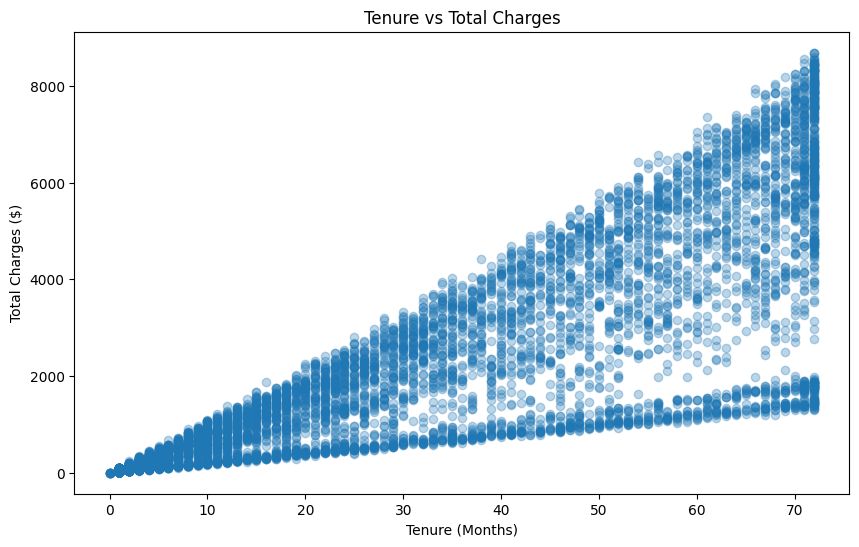

In [563]:
# Visualize the relationship between tenure and total charges
# This helps us see whether customers who stay longer naturally accumulate
# higher total charges over time

plt.figure(figsize=(10, 6))

plt.scatter(
    df["tenure"],
    df["TotalCharges"],
    alpha=0.3
)

plt.title("Tenure vs Total Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges ($)")

plt.show()

In [564]:
# Calculate the correlation between tenure and total charges
# We want to measure how strongly these two numerical variables are related

tenure_totalcharges_corr = df["tenure"].corr(df["TotalCharges"])

tenure_totalcharges_corr

np.float64(0.8261783979502421)

<Figure size 1000x600 with 0 Axes>

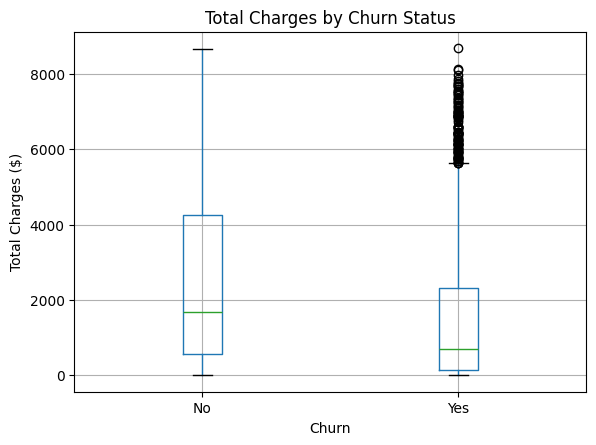

In [565]:
# Compare the distribution of total charges between customers who stayed and churned
# A boxplot helps us see the median, spread, and potential outliers in each group

plt.figure(figsize=(10, 6))

df.boxplot(
    column="TotalCharges",
    by="Churn"
)

plt.title("Total Charges by Churn Status")
plt.suptitle("")  # Remove pandas' automatic title
plt.xlabel("Churn")
plt.ylabel("Total Charges ($)")

plt.show()

<Figure size 1000x600 with 0 Axes>

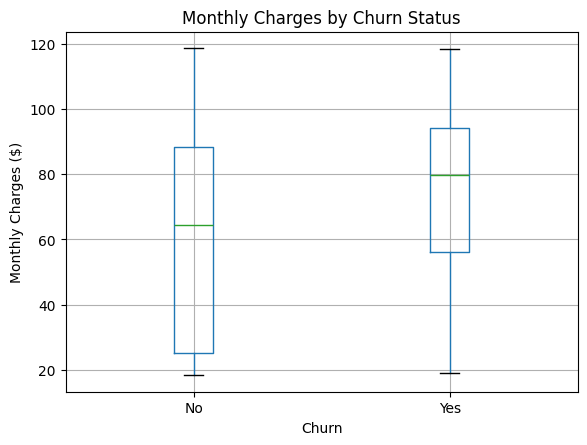

In [566]:
# Compare the distribution of monthly charges between customers who stayed and churned
# A boxplot helps us see the median, spread, and overlap between the two groups

plt.figure(figsize=(10, 6))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")  # Remove pandas' automatic title
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")

plt.show()

In [567]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA) — KEY FINDINGS
# ============================================================
# This section summarizes the most important patterns
# discovered during our exploratory analysis.
#
# These findings are observations from the dataset.
# They do NOT prove that one variable causes churn.
# ============================================================

eda_findings = {
    "Overall churn rate": "26.54%",

    "Contract": "Month-to-month customers show substantially higher churn than customers on one- or two-year contracts.",

    "Tenure": "Customers who churned had substantially shorter average tenure than customers who stayed.",

    "Monthly charges": "Customers who churned had higher average monthly charges than customers who stayed.",

    "Internet service": "Fiber optic customers showed substantially higher churn than DSL and customers without internet service.",

    "Technical support": "Customers without technical support showed substantially higher churn than customers with technical support.",

    "Online security": "Customers without online security showed substantially higher churn than customers with online security.",

    "Online backup": "Customers without online backup showed higher churn than customers with online backup.",

    "Device protection": "Customers without device protection showed higher churn than customers with device protection.",

    "Payment method": "Electronic-check customers showed substantially higher churn than customers using other payment methods.",

    "Paperless billing": "Customers using paperless billing showed higher churn than customers who did not.",

    "Demographics": "Senior citizens, customers without partners, and customers without dependents showed higher observed churn.",

    "Gender": "Churn rates were very similar between male and female customers.",

    "Streaming services": "Streaming TV and Streaming Movies showed relatively small differences in churn rates.",

    "Total charges": "Customers who stayed had higher average total charges, but TotalCharges is strongly related to tenure."
}

# Display our findings
for finding, observation in eda_findings.items():
    print(f"\n{finding}:")
    print(f"  {observation}")


Overall churn rate:
  26.54%

Contract:
  Month-to-month customers show substantially higher churn than customers on one- or two-year contracts.

Tenure:
  Customers who churned had substantially shorter average tenure than customers who stayed.

Monthly charges:
  Customers who churned had higher average monthly charges than customers who stayed.

Internet service:
  Fiber optic customers showed substantially higher churn than DSL and customers without internet service.

Technical support:
  Customers without technical support showed substantially higher churn than customers with technical support.

Online security:
  Customers without online security showed substantially higher churn than customers with online security.

Online backup:
  Customers without online backup showed higher churn than customers with online backup.

Device protection:
  Customers without device protection showed higher churn than customers with device protection.

Payment method:
  Electronic-check customers

In [568]:
# Create a separate copy of the cleaned dataset for machine learning
# This protects our original dataframe from accidental changes

ml_df = df.copy()

# Display the shape to confirm that we copied the dataset correctly
ml_df.shape

(7043, 21)

In [569]:
# Remove customerID because it is only an identifier.
# It does not describe customer behaviour and should not be used
# as a predictive feature.

ml_df = ml_df.drop(columns=["customerID"])

# Check the new shape
ml_df.shape

(7043, 20)

In [570]:
# Separate the dataset into:
# X = features used by the model to make predictions
# y = target variable that the model will learn to predict

X = ml_df.drop(columns=["Churn"])
y = ml_df["Churn"]

# Check the shapes of X and y
print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (7043, 19)
Target (y): (7043,)


In [571]:
# Import the function used to split our data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing data
# 80% will be used to train the model
# 20% will be reserved for testing
# random_state=42 ensures we get the same split every time we run the code

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Check the size of each dataset
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [572]:
# Convert the target variable from text into numbers
# 0 = Customer stayed
# 1 = Customer churned

y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

# Check the result
print("Training target values:")
print(y_train.value_counts())

print("\nTesting target values:")
print(y_test.value_counts())

Training target values:
Churn
0    4138
1    1496
Name: count, dtype: int64

Testing target values:
Churn
0    1036
1     373
Name: count, dtype: int64


In [573]:
# Identify numerical and categorical features
# Numerical features contain numbers that can be used directly by the model.
# Categorical features contain labels/text that need to be encoded.

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [574]:
# Import tools needed for preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create a preprocessing step
# Numerical columns will pass through unchanged.
# Categorical columns will be converted into numerical values
# using one-hot encoding.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

# Display the preprocessing setup
preprocessor

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod']),
                                ('numerical', 'passthrough',
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges'])])

In [575]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create a machine-learning pipeline
# Step 1: preprocess the data
# Step 2: train the Logistic Regression model

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

# Display the pipeline
logistic_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('numerical', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [576]:
# Train the Logistic Regression model using the training data
# The model learns relationships between customer characteristics
# and the likelihood of churn.

logistic_pipeline.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [577]:
# Import StandardScaler
# StandardScaler puts numerical variables on a comparable scale,
# which can help Logistic Regression converge more effectively.

from sklearn.preprocessing import StandardScaler

# Create an improved preprocessing pipeline
# Categorical variables → One-Hot Encoding
# Numerical variables → Standardization

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

preprocessor_scaled

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod']),
                                ('numerical', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges'])])

In [578]:
# Create an improved Logistic Regression pipeline
# using the scaled numerical features.

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('numerical', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [579]:
# Train the improved Logistic Regression model

logistic_pipeline.fit(X_train, y_train)

print("Improved model training completed successfully.")

Improved model training completed successfully.


In [580]:
# Use the trained model to predict whether customers in the test set
# will churn (1) or stay (0).

y_pred = logistic_pipeline.predict(X_test)

# Display the first 20 predictions
y_pred[:20]

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0])

In [581]:
# Import the accuracy metric
from sklearn.metrics import accuracy_score

# Compare the model's predictions with the actual test results
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 82.19%


In [582]:
# Import the confusion matrix function
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[934 102]
 [149 224]]


In [583]:
# Import additional classification metrics
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision
precision = precision_score(y_test, y_pred)

# Calculate recall
recall = recall_score(y_test, y_pred)

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-score:  {f1:.2%}")

Precision: 68.71%
Recall:    60.05%
F1-score:  64.09%


In [584]:
# Generate the probability that each test customer will churn
# [:, 1] selects the probability of class 1, where:
# 1 = churn

y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

# Display the first 20 churn probabilities
y_proba[:20]

array([0.69377186, 0.06075205, 0.00445622, 0.60941479, 0.0058236 ,
       0.28350631, 0.04851325, 0.00375396, 0.0495865 , 0.19921702,
       0.19705295, 0.36675863, 0.19434688, 0.53325661, 0.11492807,
       0.74041617, 0.38654138, 0.66545845, 0.47550871, 0.48781388])

In [585]:
# Import the metrics we need
from sklearn.metrics import precision_score, recall_score, f1_score

# Test different probability thresholds
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:

    # Convert probabilities into predictions using the chosen threshold
    y_pred_threshold = (y_proba >= threshold).astype(int)

    # Calculate evaluation metrics
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(f"\nThreshold: {threshold:.2f}")
    print(f"Precision: {precision:.2%}")
    print(f"Recall:    {recall:.2%}")
    print(f"F1-score:  {f1:.2%}")


Threshold: 0.30
Precision: 55.37%
Recall:    80.16%
F1-score:  65.50%

Threshold: 0.40
Precision: 60.19%
Recall:    69.71%
F1-score:  64.60%

Threshold: 0.50
Precision: 68.71%
Recall:    60.05%
F1-score:  64.09%

Threshold: 0.60
Precision: 74.76%
Recall:    42.09%
F1-score:  53.86%

Threshold: 0.70
Precision: 82.61%
Recall:    20.38%
F1-score:  32.69%


In [586]:
# Import the ROC-AUC metric
from sklearn.metrics import roc_auc_score

# Calculate the ROC-AUC score using the model's churn probabilities
roc_auc = roc_auc_score(y_test, y_proba)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8622


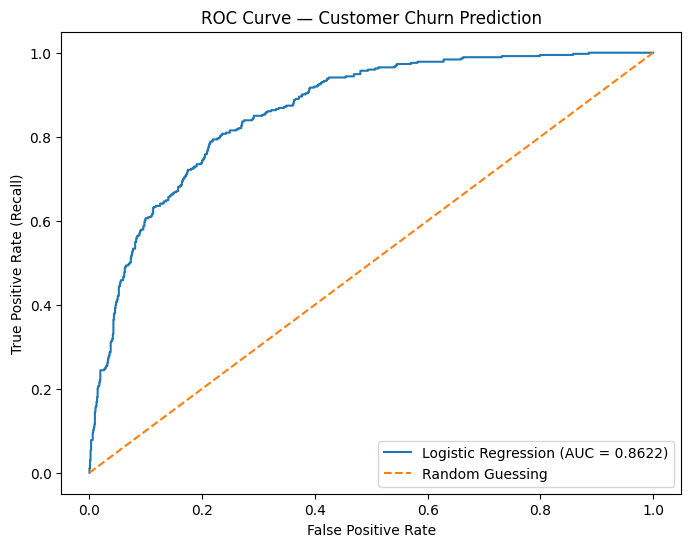

In [587]:
# Import the tools needed to calculate and plot the ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate False Positive Rate and True Positive Rate
# at different probability thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Create the ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

# Add the random-guessing baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guessing"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Customer Churn Prediction")
plt.legend()

plt.show()

In [588]:
# Extract the trained preprocessing step
trained_preprocessor = logistic_pipeline.named_steps["preprocessor"]

# Extract the trained Logistic Regression model
trained_model = logistic_pipeline.named_steps["model"]

# Get the names of all features after one-hot encoding
feature_names = trained_preprocessor.get_feature_names_out()

# Get the Logistic Regression coefficients
coefficients = trained_model.coef_[0]

# Create a dataframe containing each feature and its coefficient
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by coefficient
coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_df.head(15)

,Feature,Coefficient
44,numerical__TotalCharges,0.656542
32,categorical__Contract_Month-to-month,0.595950
12,categorical__InternetService_Fiber optic,0.505609
39,categorical__PaymentMethod_Electronic check,0.197630
31,categorical__StreamingMovies_Yes,0.172816
14,categorical__OnlineSecurity_No,0.171837
23,categorical__TechSupport_No,0.130420
28,categorical__StreamingTV_Yes,0.123604
41,numerical__SeniorCitizen,0.059295
17,categorical__OnlineBackup_No,0.043777


In [589]:
# Show the features with the strongest negative coefficients
# Negative coefficients push the model toward predicting lower churn probability.

coefficient_df.tail(15).sort_values(
    by="Coefficient",
    ascending=True
)

,Feature,Coefficient
42,numerical__tenure,-1.355812
34,categorical__Contract_Two year,-0.833243
11,categorical__InternetService_DSL,-0.551484
43,numerical__MonthlyCharges,-0.399027
35,categorical__PaperlessBilling_No,-0.313091
8,categorical__MultipleLines_No,-0.269195
27,categorical__StreamingTV_No internet service,-0.245750
24,categorical__TechSupport_No internet service,-0.245750
13,categorical__InternetService_No,-0.245750
15,categorical__OnlineSecurity_No internet service,-0.245750


In [590]:
# Import the Decision Tree classification algorithm.
# DecisionTreeClassifier is designed for predicting categorical outcomes,
# such as our Churn target: 0 = stayed, 1 = churned.

from sklearn.tree import DecisionTreeClassifier

In [591]:
# Create a complete machine-learning pipeline.
#
# The pipeline has two stages:
#
# 1. Preprocessor
#    - Scales our numerical features
#    - One-hot encodes our categorical features
#
# 2. Decision Tree
#    - Learns patterns from the processed training data
#    - Predicts whether a customer will churn or stay

decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_scaled
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

# Display the pipeline so we can confirm that
# the preprocessing and Decision Tree are connected correctly.

decision_tree_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('numerical', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [592]:
# Train the Decision Tree using ONLY the training data.
#
# X_train contains the customer features.
# y_train contains the actual churn outcomes.
#
# The Decision Tree will learn patterns that help it distinguish
# between customers who stayed (0) and customers who churned (1).

decision_tree_pipeline.fit(X_train, y_train)

# Confirm that training completed successfully.

print("Decision Tree training completed successfully.")

Decision Tree training completed successfully.


In [593]:
# Use the trained Decision Tree to predict churn outcomes
# for customers in our unseen test dataset.
#
# The model will return:
# 0 = predicted to stay
# 1 = predicted to churn

y_pred_tree = decision_tree_pipeline.predict(X_test)

# Display the first 20 predictions
# This lets us confirm that the model is producing predictions correctly.

y_pred_tree[:20]

array([1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1])

In [594]:
# Import the evaluation metrics.
# We already imported some of these earlier, but importing them again
# here makes this cell easy to understand and run independently.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate Accuracy
# This measures the proportion of all test predictions
# that the Decision Tree got correct.

tree_accuracy = accuracy_score(y_test, y_pred_tree)

# Calculate Precision
# Of the customers predicted to churn,
# what percentage actually churned?

tree_precision = precision_score(y_test, y_pred_tree)

# Calculate Recall
# Of all customers who actually churned,
# what percentage did the model successfully identify?

tree_recall = recall_score(y_test, y_pred_tree)

# Calculate F1-score
# This combines precision and recall into a single metric.

tree_f1 = f1_score(y_test, y_pred_tree)

# Display the results

print(f"Accuracy:  {tree_accuracy:.2%}")
print(f"Precision: {tree_precision:.2%}")
print(f"Recall:    {tree_recall:.2%}")
print(f"F1-score:  {tree_f1:.2%}")

Accuracy:  72.04%
Precision: 47.34%
Recall:    50.13%
F1-score:  48.70%


In [595]:
# Generate predictions on the training data.
# This tells us how well the Decision Tree performs
# on the customers it already learned from.

y_train_pred_tree = decision_tree_pipeline.predict(X_train)

# Calculate training accuracy.

tree_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_tree
)

# Display the training accuracy.

print(f"Decision Tree Training Accuracy: {tree_train_accuracy:.2%}")

Decision Tree Training Accuracy: 99.86%


In [596]:
# Test several maximum tree depths.
#
# A smaller max_depth creates a simpler tree.
# A larger max_depth allows the tree to learn more complex patterns.
#
# We're testing several values so we can see how tree complexity
# affects training and testing performance.

depths = [3, 5, 7, 10]

for depth in depths:

    # Create a Decision Tree with the current maximum depth.
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    # Create a pipeline so the exact same preprocessing
    # is applied before the Decision Tree.
    tree_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_scaled),
            ("model", tree)
        ]
    )

    # Train the tree using only the training data.
    tree_pipeline.fit(X_train, y_train)

    # Make predictions on the training data.
    train_predictions = tree_pipeline.predict(X_train)

    # Make predictions on the unseen test data.
    test_predictions = tree_pipeline.predict(X_test)

    # Calculate training accuracy.
    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    # Calculate testing accuracy.
    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    # Display the results.
    print(
        f"max_depth={depth} | "
        f"Training Accuracy={train_accuracy:.2%} | "
        f"Testing Accuracy={test_accuracy:.2%}"
    )

max_depth=3 | Training Accuracy=78.90% | Testing Accuracy=79.56%
max_depth=5 | Training Accuracy=79.98% | Testing Accuracy=79.99%
max_depth=7 | Training Accuracy=82.07% | Testing Accuracy=79.49%
max_depth=10 | Training Accuracy=87.49% | Testing Accuracy=76.22%


In [597]:
# Create our tuned Decision Tree using the best depth
# we found from our initial testing.
#
# max_depth=5 limits the complexity of the tree and helps
# reduce the overfitting we observed with the unrestricted tree.

tuned_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_scaled
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

# Train the tuned Decision Tree on the training data.

tuned_tree_pipeline.fit(X_train, y_train)

print("Tuned Decision Tree training completed successfully.")

Tuned Decision Tree training completed successfully.


In [598]:
# Use the tuned Decision Tree to predict churn
# for the unseen test customers.

y_pred_tuned_tree = tuned_tree_pipeline.predict(X_test)

# Display the first 20 predictions so we can confirm
# that the tuned model is working correctly.

y_pred_tuned_tree[:20]

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1])

In [599]:
# Import the evaluation metrics.
# These are the same metrics we used to evaluate Logistic Regression,
# allowing us to make a fair comparison between the models.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate the overall percentage of correct predictions.

tuned_tree_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_tree
)

# Calculate precision.
# Of all customers the model predicted would churn,
# how many actually churned?

tuned_tree_precision = precision_score(
    y_test,
    y_pred_tuned_tree
)

# Calculate recall.
# Of all customers who actually churned,
# how many did our model successfully identify?

tuned_tree_recall = recall_score(
    y_test,
    y_pred_tuned_tree
)

# Calculate F1-score.
# This gives us a balance between precision and recall.

tuned_tree_f1 = f1_score(
    y_test,
    y_pred_tuned_tree
)

# Display all four metrics.

print(f"Accuracy:  {tuned_tree_accuracy:.2%}")
print(f"Precision: {tuned_tree_precision:.2%}")
print(f"Recall:    {tuned_tree_recall:.2%}")
print(f"F1-score:  {tuned_tree_f1:.2%}")

Accuracy:  79.99%
Precision: 61.88%
Recall:    63.54%
F1-score:  62.70%


In [600]:
# Get the Decision Tree's predicted probability of churn.
#
# predict_proba() returns two probabilities for each customer:
#
# [probability of staying, probability of churning]
#
# [:, 1] selects the probability of class 1,
# which represents CHURN.

y_proba_tree = tuned_tree_pipeline.predict_proba(X_test)[:, 1]

# Display the first 20 churn probabilities.

y_proba_tree[:20]

array([0.54666667, 0.09310345, 0.01346389, 0.83552632, 0.01346389,
       0.16666667, 0.01346389, 0.01346389, 0.11891892, 0.29756098,
       0.29756098, 0.35798817, 0.11      , 0.51643192, 0.21342926,
       0.74475524, 0.21342926, 0.83552632, 0.51643192, 0.51643192])

In [601]:
# Import the ROC-AUC metric.
# ROC-AUC measures how well the model can distinguish
# between customers who churn and customers who stay
# across different probability thresholds.

from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC using the Decision Tree's
# predicted probability of churn.

tree_roc_auc = roc_auc_score(
    y_test,
    y_proba_tree
)

# Display the result.

print(f"Decision Tree ROC-AUC: {tree_roc_auc:.4f}")

Decision Tree ROC-AUC: 0.8400


In [602]:
# Import the Random Forest classification algorithm.
#
# A Random Forest combines many Decision Trees.
# Each tree learns from slightly different samples/features,
# and their predictions are combined to produce a stronger model.

from sklearn.ensemble import RandomForestClassifier

In [603]:
# Create our Random Forest pipeline.
#
# The pipeline ensures that the same preprocessing used by
# our previous models is applied here as well.

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_scaled
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Display the pipeline to confirm that
# preprocessing and Random Forest are connected.

random_forest_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('numerical', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [604]:
# Train the Random Forest using our training data.
#
# X_train contains the 5,634 customers that the model is allowed
# to learn from.
#
# y_train contains their actual churn outcomes:
# 0 = stayed
# 1 = churned.
#
# The pipeline will first:
#   1. One-hot encode categorical variables
#   2. Scale numerical variables
#   3. Feed the processed data into the Random Forest
#   4. Train the 200 decision trees

random_forest_pipeline.fit(
    X_train,
    y_train
)

# Confirm that training has completed.

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


In [605]:
# Use the trained Random Forest to predict whether
# each customer in our unseen test dataset will churn.
#
# 0 = predicted to stay
# 1 = predicted to churn
#
# The pipeline automatically performs the necessary preprocessing
# before sending the data through the Random Forest.

y_pred_rf = random_forest_pipeline.predict(X_test)

# Display the first 20 predictions.
# This allows us to confirm that the model is producing
# predictions successfully.

y_pred_rf[:20]

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0])

In [606]:
# Import the classification metrics we need.
#
# Accuracy  → Overall percentage of correct predictions
# Precision → How reliable our churn predictions are
# Recall    → How many actual churners we successfully identify
# F1-score  → Balance between precision and recall

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ---------------------------------------------------------
# 1. ACCURACY
# ---------------------------------------------------------
# Compare the Random Forest's predictions with the actual
# churn outcomes in our test dataset.
#
# y_test      = actual outcomes
# y_pred_rf  = Random Forest predictions

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)


# ---------------------------------------------------------
# 2. PRECISION
# ---------------------------------------------------------
# Of everyone the Random Forest predicted would churn,
# what percentage actually churned?
#
# High precision means fewer false alarms.

rf_precision = precision_score(
    y_test,
    y_pred_rf
)


# ---------------------------------------------------------
# 3. RECALL
# ---------------------------------------------------------
# Of all the customers who actually churned,
# what percentage did our Random Forest successfully identify?
#
# High recall is particularly valuable if our business goal
# is to catch as many potential churners as possible.

rf_recall = recall_score(
    y_test,
    y_pred_rf
)


# ---------------------------------------------------------
# 4. F1-SCORE
# ---------------------------------------------------------
# F1 combines precision and recall into a single metric.
#
# It is especially useful when we care about BOTH:
#   - catching churners
#   - avoiding too many false alarms

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)


# ---------------------------------------------------------
# DISPLAY THE RESULTS
# ---------------------------------------------------------

print(f"Accuracy:  {rf_accuracy:.2%}")
print(f"Precision: {rf_precision:.2%}")
print(f"Recall:    {rf_recall:.2%}")
print(f"F1-score:  {rf_f1:.2%}")

Accuracy:  79.13%
Precision: 64.91%
Recall:    46.11%
F1-score:  53.92%


In [607]:
# Generate predictions for the training customers.
#
# These are the same 5,634 customers the Random Forest
# was trained on.

y_train_pred_rf = random_forest_pipeline.predict(X_train)


# Calculate training accuracy.

rf_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_rf
)


# Display the training accuracy.

print(f"Random Forest Training Accuracy: {rf_train_accuracy:.2%}")

Random Forest Training Accuracy: 99.86%


In [608]:
# Create a new Random Forest with two important changes:
#
# 1. max_depth=7
#    Limits how deep each individual tree can grow.
#    This helps control the overfitting we observed.
#
# 2. class_weight="balanced"
#    Gives more importance to the minority class (Churn = 1).
#    This may help the model identify more customers who are
#    actually going to churn.
#
# We keep:
#
# n_estimators=200
#    So our forest still contains 200 decision trees.
#
# random_state=42
#    So our results remain reproducible.
#
# n_jobs=-1
#    Uses available CPU cores to speed up training.

balanced_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_scaled
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=7,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Display the pipeline to confirm that everything
# has been connected correctly.

balanced_rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('numerical', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=7,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [609]:
# Train the improved Random Forest using the training dataset.
#
# The pipeline will:
# 1. Preprocess the categorical variables.
# 2. Standardize the numerical variables.
# 3. Train 200 controlled decision trees.
# 4. Give additional weight to the minority churn class.

balanced_rf_pipeline.fit(
    X_train,
    y_train
)

print("Balanced Random Forest training completed successfully.")

Balanced Random Forest training completed successfully.


In [610]:
# Ask our improved Random Forest to predict
# whether each customer in the test set will churn.

y_pred_balanced_rf = balanced_rf_pipeline.predict(X_test)

# Show the first 20 predictions.

y_pred_balanced_rf[:20]

array([1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1])

In [611]:
# Check how good our new Random Forest predictions are.

balanced_rf_accuracy = accuracy_score(
    y_test,
    y_pred_balanced_rf
)

balanced_rf_precision = precision_score(
    y_test,
    y_pred_balanced_rf
)

balanced_rf_recall = recall_score(
    y_test,
    y_pred_balanced_rf
)

balanced_rf_f1 = f1_score(
    y_test,
    y_pred_balanced_rf
)

print(f"Accuracy:  {balanced_rf_accuracy:.2%}")
print(f"Precision: {balanced_rf_precision:.2%}")
print(f"Recall:    {balanced_rf_recall:.2%}")
print(f"F1-score:  {balanced_rf_f1:.2%}")

Accuracy:  76.51%
Precision: 53.66%
Recall:    82.57%
F1-score:  65.05%


In [612]:
# Ask the Random Forest:
# "How likely is each customer to churn?"
#
# Instead of simply giving us 0 or 1,
# this gives us a probability between 0 and 1.

y_proba_balanced_rf = balanced_rf_pipeline.predict_proba(X_test)[:, 1]

# Show the first 20 probabilities.

y_proba_balanced_rf[:20]

array([0.79806507, 0.18685607, 0.02191717, 0.85678635, 0.12191198,
       0.5291515 , 0.09220362, 0.03825634, 0.28080918, 0.51637271,
       0.50507681, 0.59998843, 0.31858715, 0.666806  , 0.22059081,
       0.83497166, 0.60251015, 0.86061922, 0.67792323, 0.70688067])

In [613]:
# Calculate the ROC-AUC of our improved Random Forest.

balanced_rf_roc_auc = roc_auc_score(
    y_test,
    y_proba_balanced_rf
)

print(f"Balanced Random Forest ROC-AUC: {balanced_rf_roc_auc:.4f}")

Balanced Random Forest ROC-AUC: 0.8653


In [614]:
# We will test several probability thresholds.
#
# Remember:
#
# 0.30 means:
# If the model thinks there is at least a 30% chance
# of churn, classify the customer as a churner.
#
# 0.50 means:
# At least a 50% chance is required.
#
# A lower threshold usually catches more churners,
# while a higher threshold usually gives fewer false alarms.

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:

    # Turn probabilities into 0/1 predictions
    # using the current threshold.

    y_pred_threshold = (
        y_proba_balanced_rf >= threshold
    ).astype(int)

    # Calculate the three metrics we care about.

    precision = precision_score(
        y_test,
        y_pred_threshold
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2%} | "
        f"Recall: {recall:.2%} | "
        f"F1-score: {f1:.2%}"
    )

Threshold: 0.30 | Precision: 42.42% | Recall: 93.83% | F1-score: 58.43%
Threshold: 0.40 | Precision: 47.84% | Recall: 89.28% | F1-score: 62.30%
Threshold: 0.50 | Precision: 53.66% | Recall: 82.57% | F1-score: 65.05%
Threshold: 0.60 | Precision: 61.33% | Recall: 71.85% | F1-score: 66.17%
Threshold: 0.70 | Precision: 69.73% | Recall: 54.96% | F1-score: 61.47%


In [615]:
# Get the names of all features after preprocessing.
#
# This includes:
# - the one-hot encoded categorical features
# - the numerical features

feature_names = (
    balanced_rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get the importance score for each feature
# from the trained Random Forest.

feature_importances = (
    balanced_rf_pipeline
    .named_steps["model"]
    .feature_importances_
)

# Put the feature names and their importance scores
# into a table.

rf_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Sort the table from most important to least important.

rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show the 15 most important features.

rf_feature_importance.head(15)

,Feature,Importance
32,categorical__Contract_Month-to-month,0.149255
42,numerical__tenure,0.122711
44,numerical__TotalCharges,0.084156
34,categorical__Contract_Two year,0.083257
14,categorical__OnlineSecurity_No,0.074327
12,categorical__InternetService_Fiber optic,0.055536
23,categorical__TechSupport_No,0.054435
43,numerical__MonthlyCharges,0.054052
39,categorical__PaymentMethod_Electronic check,0.044738
33,categorical__Contract_One year,0.022957


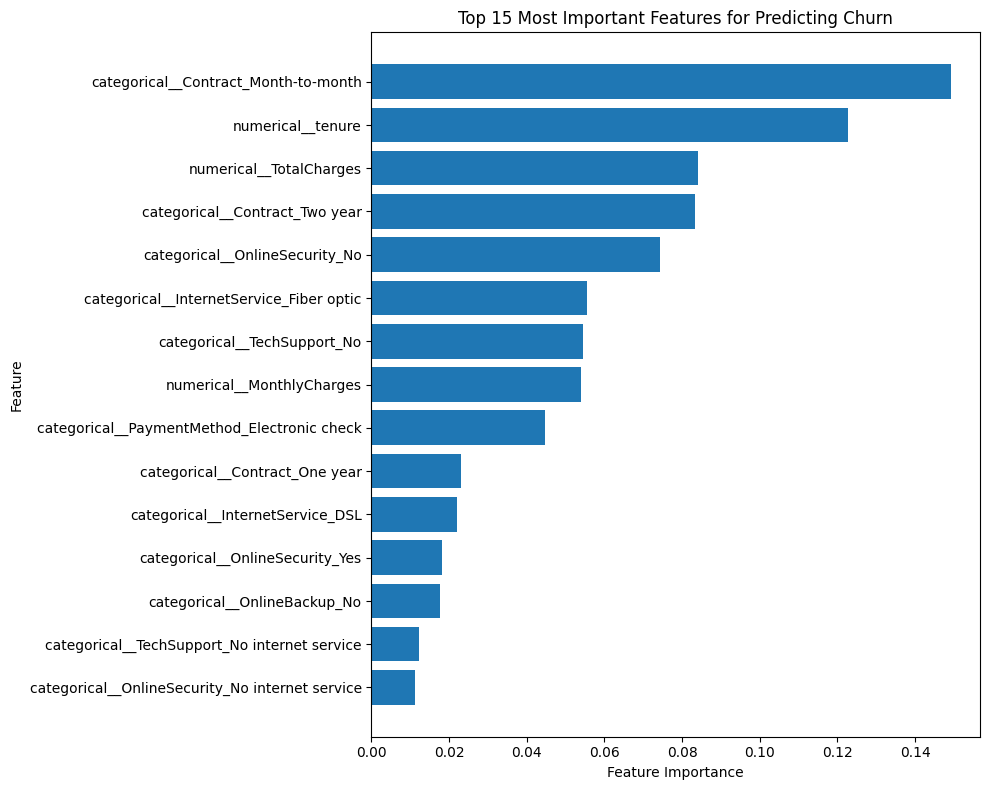

In [616]:
# Import matplotlib so we can create the chart.

import matplotlib.pyplot as plt


# Take only the 15 most important features.

top_15_features = rf_feature_importance.head(15)


# Create the chart.

plt.figure(figsize=(10, 8))

plt.barh(
    top_15_features["Feature"],
    top_15_features["Importance"]
)


# Put the most important feature at the top.

plt.gca().invert_yaxis()


# Add labels.

plt.title("Top 15 Most Important Features for Predicting Churn")

plt.xlabel("Feature Importance")

plt.ylabel("Feature")


# Make sure everything fits nicely.

plt.tight_layout()


# Show the chart.

plt.show()

In [617]:
# Import the permutation importance tool.

from sklearn.inspection import permutation_importance


# Test how important each ORIGINAL feature is.
#
# We use X_test because these are customers the model
# did not see during training.
#
# roc_auc is used as our scoring method because ROC-AUC
# is one of the main metrics we have been using to judge
# how well the model ranks churn risk.

permutation_results = permutation_importance(
    balanced_rf_pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


# Put the results into a table.

permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation_results.importances_mean
})


# Sort from most important to least important.

permutation_importance_df = permutation_importance_df.sort_values(
    by="Importance",
    ascending=False
)


# Show the 15 most important features.

permutation_importance_df.head(15)

,Feature,Importance
14,Contract,0.088309
7,InternetService,0.026677
4,tenure,0.021163
18,TotalCharges,0.009210
8,OnlineSecurity,0.005650
16,PaymentMethod,0.004439
11,TechSupport,0.004426
15,PaperlessBilling,0.002277
17,MonthlyCharges,0.001868
9,OnlineBackup,0.001199


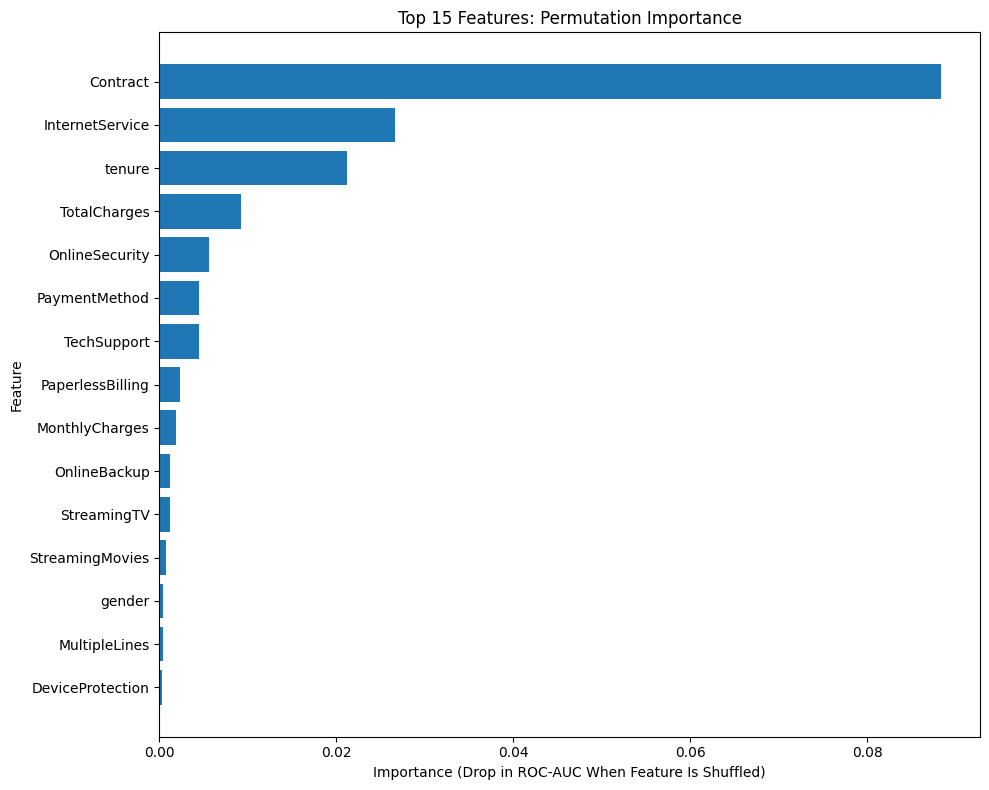

In [618]:
# Take the top 15 most important original features.

top_15_permutation = permutation_importance_df.head(15)


# Create a bar chart.

plt.figure(figsize=(10, 8))

plt.barh(
    top_15_permutation["Feature"],
    top_15_permutation["Importance"]
)


# Put the most important feature at the top.

plt.gca().invert_yaxis()


# Add a clear title and labels.

plt.title(
    "Top 15 Features: Permutation Importance"
)

plt.xlabel(
    "Importance (Drop in ROC-AUC When Feature Is Shuffled)"
)

plt.ylabel("Feature")


# Make everything fit nicely.

plt.tight_layout()

plt.show()

In [619]:
# Import the tools we need.

from sklearn.model_selection import StratifiedKFold, cross_val_score


# Create 5 folds.
#
# shuffle=True means the customers are mixed before
# being divided into the 5 groups.
#
# random_state=42 makes the result reproducible.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Test our Balanced Random Forest 5 times.
#
# We use ROC-AUC because ROC-AUC is one of our main
# measures for this churn model.

cv_scores = cross_val_score(
    balanced_rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)


# Show the ROC-AUC score from each of the 5 tests.

print("Cross-validation ROC-AUC scores:")

print(cv_scores)


# Show the average score.

print(
    f"\nAverage ROC-AUC: {cv_scores.mean():.4f}"
)


# Show how much the scores changed between the 5 tests.
#
# A smaller number generally means the results were
# more consistent across the different folds.

print(
    f"Standard Deviation: {cv_scores.std():.4f}"
)

Cross-validation ROC-AUC scores:
[0.81688357 0.84072714 0.84270434 0.84150544 0.86011817]

Average ROC-AUC: 0.8404
Standard Deviation: 0.0138


In [620]:
# ============================================================
# STEP 12A — PREPARE SHAP
# ============================================================
# SHAP helps us understand WHY our machine-learning model
# makes its predictions.
#
# We are going to use SHAP to explain our Balanced Random
# Forest model.
#
# Before doing anything else, we check that SHAP is installed
# and that we are using the correct model.
# ============================================================


# Import the SHAP library.
# SHAP is the tool we will use to explain our model.

import shap


# Show the version of SHAP installed in our notebook.
# This is useful because different SHAP versions can sometimes
# behave slightly differently.

print("SHAP version:", shap.__version__)


# ------------------------------------------------------------
# GET OUR BALANCED RANDOM FOREST
# ------------------------------------------------------------
# Our Balanced Random Forest is stored inside this pipeline:
#
# balanced_rf_pipeline
#
# The pipeline has two main parts:
#
# "preprocessor" → prepares the customer data
# "model"       → contains the Random Forest
#
# We want the actual Random Forest model.

rf_model = balanced_rf_pipeline.named_steps["model"]


# Check that we successfully extracted the model.

print("\nRandom Forest model:")
print(rf_model)

SHAP version: 0.52.0

Random Forest model:
RandomForestClassifier(class_weight='balanced', max_depth=7, n_estimators=200,
                       n_jobs=-1, random_state=42)


In [621]:
# ============================================================
# STEP 12B — PREPARE TEST DATA FOR SHAP
# ============================================================
# Our Random Forest does not directly see the original
# customer data.
#
# First, our preprocessor:
#   1. Converts text categories into numbers.
#   2. Scales our numerical features.
#
# This changes our original 19 features into 45 features.
#
# SHAP must explain these same 45 features because these
# are the features the Random Forest actually uses.
# ============================================================


# Get the preprocessing part of our Balanced Random Forest.

rf_preprocessor = balanced_rf_pipeline.named_steps["preprocessor"]


# Transform our test data using the SAME preprocessing
# that was used when training the Random Forest.
#
# X_test contains the original 19 features.

X_test_transformed = rf_preprocessor.transform(X_test)


# Sometimes OneHotEncoder gives us a sparse matrix.
# SHAP works more easily with a normal/dense array.
#
# So, if the data is sparse, we convert it to a normal array.

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()


# Get the names of the 45 features created by preprocessing.
#
# This is important because later we want to know exactly
# which feature SHAP is talking about.

rf_feature_names = rf_preprocessor.get_feature_names_out()


# ------------------------------------------------------------
# CHECK OUR RESULTS
# ------------------------------------------------------------
# These checks help us make sure everything is correct
# before moving to the actual SHAP calculations.

print("Original test data shape:", X_test.shape)

print(
    "Transformed test data shape:",
    X_test_transformed.shape
)

print(
    "Number of transformed features:",
    len(rf_feature_names)
)


# Show the first 10 transformed feature names.
# This lets us see what the Random Forest actually receives.

print("\nFirst 10 transformed features:")

print(rf_feature_names[:10])

Original test data shape: (1409, 19)
Transformed test data shape: (1409, 45)
Number of transformed features: 45

First 10 transformed features:
['categorical__gender_Female' 'categorical__gender_Male'
 'categorical__Partner_No' 'categorical__Partner_Yes'
 'categorical__Dependents_No' 'categorical__Dependents_Yes'
 'categorical__PhoneService_No' 'categorical__PhoneService_Yes'
 'categorical__MultipleLines_No'
 'categorical__MultipleLines_No phone service']


In [622]:
# ============================================================
# STEP 12C — CREATE THE SHAP EXPLAINER
# ============================================================
# Our model is a Random Forest.
#
# Random Forest is made from many decision trees.
#
# SHAP has a special tool called TreeExplainer that is
# designed to explain tree-based models.
#
# We will give TreeExplainer our trained Random Forest.
# ============================================================


# Create the SHAP explainer.
#
# rf_model is our trained Balanced Random Forest.

explainer = shap.TreeExplainer(rf_model)


# Confirm that the explainer was created successfully.

print("SHAP TreeExplainer created successfully.")


# Show the type of explainer we created.
# This is just a quick check that SHAP is using
# the correct type of explainer.

print("\nExplainer type:")

print(type(explainer))

SHAP TreeExplainer created successfully.

Explainer type:
<class 'shap.explainers._tree.TreeExplainer'>


In [623]:
# ============================================================
# STEP 12D — CALCULATE SHAP VALUES
# ============================================================
# We now have:
#
#   1. Our trained Random Forest → rf_model
#   2. Our SHAP explainer       → explainer
#   3. Our transformed test data → X_test_transformed
#
# We will now ask SHAP to explain the predictions
# made by our Random Forest.
#
# Each SHAP value tells us how much a feature contributed
# to a prediction.
# ============================================================


# Calculate SHAP values for all customers in our test set.

shap_values = explainer.shap_values(
    X_test_transformed
)


# Confirm that SHAP finished successfully.

print("SHAP values calculated successfully.")


# Show the type of SHAP output.

print("\nSHAP output type:")

print(type(shap_values))


# Show the shape of the SHAP output.
#
# SHAP 0.52.0 can return different formats depending
# on the model/output configuration.
#
# So we check the result instead of assuming its format.

if isinstance(shap_values, list):

    print("\nSHAP returned a list.")

    print(
        "Number of output classes:",
        len(shap_values)
    )

    for i, values in enumerate(shap_values):

        print(
            f"Class {i} shape:",
            values.shape
        )

else:

    print("\nSHAP returned an array.")

    print(
        "SHAP shape:",
        shap_values.shape
    )

SHAP values calculated successfully.

SHAP output type:
<class 'numpy.ndarray'>

SHAP returned an array.
SHAP shape: (1409, 45, 2)


In [624]:
# ============================================================
# STEP 12E — EXTRACT SHAP VALUES FOR CHURN
# ============================================================
# Our SHAP result has three dimensions:
#
#   1. Customers
#   2. Features
#   3. Prediction classes
#
# The last dimension contains:
#
#   0 = Stayed
#   1 = Churned
#
# We are interested in churn.
# Therefore, we select class 1.
# ============================================================


# Select the SHAP values for the churn class.
#
# The ":, :" means:
#   - take all customers
#   - take all features
#
# The final "1" means:
#   - take class 1 = churn

shap_values_churn = shap_values[:, :, 1]


# Check the new shape.

print("SHAP values for churn shape:")

print(shap_values_churn.shape)


# Confirm that the number of customers matches
# our test dataset.

print("\nNumber of test customers:")

print(X_test.shape[0])


# Confirm that the number of features matches
# our transformed feature list.

print("\nNumber of transformed features:")

print(len(rf_feature_names))

SHAP values for churn shape:
(1409, 45)

Number of test customers:
1409

Number of transformed features:
45


In [625]:
# ============================================================
# STEP 12F — SHAP FEATURE IMPORTANCE
# ============================================================
# SHAP gives us a value for every feature for every customer.
#
# Some SHAP values are positive.
# Some SHAP values are negative.
#
# Positive SHAP value:
#   The feature pushed the prediction toward CHURN.
#
# Negative SHAP value:
#   The feature pushed the prediction toward STAYING.
#
# We want to know which features have the biggest
# influence overall.
#
# To find this, we calculate the average absolute SHAP value.
#
# "Absolute" means we ignore whether the influence was
# positive or negative.
#
# We only care about the SIZE of the influence.
# ============================================================


# Calculate the average absolute SHAP value
# for every feature.

mean_shap_importance = (
    abs(shap_values_churn).mean(axis=0)
)


# Create a table containing:
#   Feature name
#   Average SHAP importance

shap_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "SHAP Importance": mean_shap_importance
})


# Sort the features from most important
# to least important.

shap_importance_df = shap_importance_df.sort_values(
    by="SHAP Importance",
    ascending=False
)


# Show the 15 most influential features.

print("Top 15 features according to SHAP:")

shap_importance_df.head(15)

Top 15 features according to SHAP:


,Feature,SHAP Importance
32,categorical__Contract_Month-to-month,0.073450
42,numerical__tenure,0.048374
34,categorical__Contract_Two year,0.039978
12,categorical__InternetService_Fiber optic,0.038849
14,categorical__OnlineSecurity_No,0.036337
23,categorical__TechSupport_No,0.026494
44,numerical__TotalCharges,0.025391
39,categorical__PaymentMethod_Electronic check,0.023822
11,categorical__InternetService_DSL,0.017863
43,numerical__MonthlyCharges,0.015345


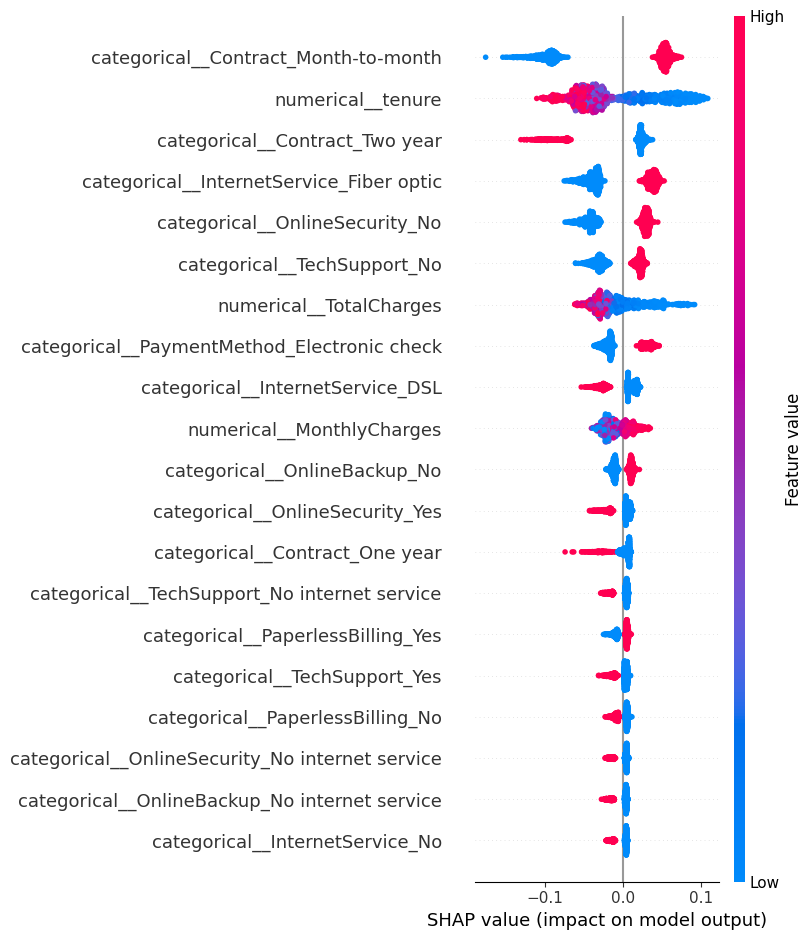

In [626]:
# ============================================================
# STEP 12G — SHAP SUMMARY PLOT
# ============================================================
# Our previous table told us which features are important.
#
# Now we want to see something more useful:
#
#   Does a feature push the customer toward CHURN?
#   Or does it push the customer toward STAYING?
#
# The SHAP summary plot shows both things at the same time.
#
# Each dot represents one customer.
#
# The position of the dot tells us whether the feature
# pushed the prediction toward or away from churn.
#
# The colour tells us whether the customer's feature value
# was high or low.
# ============================================================


# Create the SHAP summary plot.

shap.summary_plot(
    shap_values_churn,
    X_test_transformed,
    feature_names=rf_feature_names,
    show=True
)

In [627]:
# ============================================================
# STEP 12H — EXPLAIN ONE CUSTOMER'S PREDICTION
# ============================================================
# We are going to choose ONE customer from our test data.
#
# Then we will ask SHAP:
#
# "Why did our Random Forest predict this customer's
# churn risk?"
#
# This gives us a real example of how the model can
# explain its decisions.
# ============================================================


# Choose the first customer in our test dataset.

customer_index = 0


# Get this customer's original information.

customer_data = X_test.iloc[customer_index]


# Get this customer's actual churn result.

actual_churn = y_test.iloc[customer_index]


# Get this customer's predicted probability of churn.

predicted_churn_probability = (
    y_proba_balanced_rf[customer_index]
)


# Display the customer's basic information.

print("CUSTOMER INFORMATION")
print("--------------------")

print("\nActual churn:")
print(actual_churn)

print("\nPredicted probability of churn:")
print(
    f"{predicted_churn_probability:.2%}"
)


# Display the customer's original features.

print("\nCustomer features:")

print(customer_data)

CUSTOMER INFORMATION
--------------------

Actual churn:
1

Predicted probability of churn:
79.81%

Customer features:
gender                        Female
SeniorCitizen                      0
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                      No
MultipleLines       No phone service
InternetService                  DSL
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                  24.8
TotalCharges                    24.8
Name: 185, dtype: object


In [628]:
# ============================================================
# STEP 12I — EXPLAIN THIS CUSTOMER'S CHURN PREDICTION
# ============================================================
# We already know this customer has a 79.81% predicted
# probability of churn.
#
# Now we want to know WHY.
#
# We will look at this customer's individual SHAP values.
#
# Positive SHAP value:
#   Pushes the prediction toward CHURN.
#
# Negative SHAP value:
#   Pushes the prediction toward STAYING.
# ============================================================


# Get the SHAP values for our selected customer.

customer_shap_values = shap_values_churn[customer_index]


# Create a table containing:
#
#   Feature
#   SHAP value
#
# Each row represents one feature.

customer_shap_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "SHAP Value": customer_shap_values
})


# Sort by SHAP value from highest to lowest.
#
# The features at the top are pushing the prediction
# most strongly toward churn.

customer_shap_df = customer_shap_df.sort_values(
    by="SHAP Value",
    ascending=False
)


# Show the 10 strongest features pushing
# this customer toward churn.

print("Top features pushing this customer toward CHURN:")

print(
    customer_shap_df.head(10)
)


# Show the 10 strongest features pushing
# this customer toward STAYING.

print("\nTop features pushing this customer toward STAYING:")

print(
    customer_shap_df.tail(10).sort_values(
        by="SHAP Value",
        ascending=True
    )
)

Top features pushing this customer toward CHURN:
                                        Feature  SHAP Value
42                            numerical__tenure    0.076511
32         categorical__Contract_Month-to-month    0.051642
44                      numerical__TotalCharges    0.048949
14               categorical__OnlineSecurity_No    0.033361
39  categorical__PaymentMethod_Electronic check    0.030573
34               categorical__Contract_Two year    0.022429
23                  categorical__TechSupport_No    0.021984
17                 categorical__OnlineBackup_No    0.012578
16              categorical__OnlineSecurity_Yes    0.009841
33               categorical__Contract_One year    0.007437

Top features pushing this customer toward STAYING:
                                     Feature  SHAP Value
12  categorical__InternetService_Fiber optic   -0.038270
11          categorical__InternetService_DSL   -0.023706
43                 numerical__MonthlyCharges   -0.014103
3          

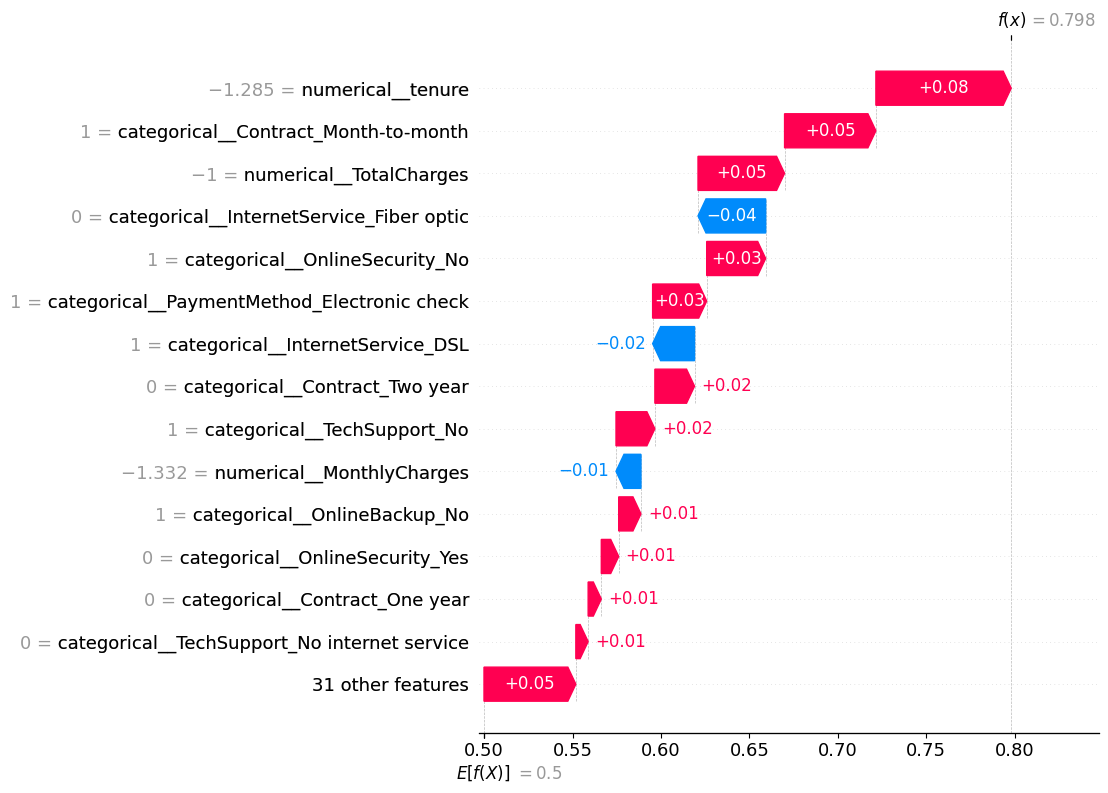

In [629]:
# ============================================================
# STEP 12J — SHAP WATERFALL PLOT
# ============================================================
# The waterfall plot shows how each feature changed
# the model's prediction for ONE customer.
#
# Think of it like a journey:
#
# Start with the model's normal/base prediction.
#
# Then:
#   Some features push the prediction UP toward churn.
#   Some features push the prediction DOWN toward staying.
#
# At the end, we arrive at this customer's prediction.
#
# This gives us a visual explanation of the prediction.
# ============================================================


# Create a SHAP Explanation object for our customer.
#
# This combines:
#   - the customer's SHAP values
#   - the customer's feature values
#   - the feature names
#
# SHAP uses this information to build the waterfall chart.

customer_explanation = shap.Explanation(
    values=customer_shap_values,
    base_values=explainer.expected_value[1],
    data=X_test_transformed[customer_index],
    feature_names=rf_feature_names
)


# Create the waterfall plot.
#
# max_display=15 means we show the 15 most influential
# features instead of displaying all 45 features.

shap.plots.waterfall(
    customer_explanation,
    max_display=15
)

In [630]:
# ============================================================
# STEP 12L — FAIR FEATURE IMPORTANCE COMPARISON
# ============================================================
# We discovered an important issue:
#
# Random Forest and SHAP use our 45 transformed features.
#
# Permutation importance uses our original 19 features.
#
# For example:
#
#     Contract_Month-to-month
#     Contract_One year
#     Contract_Two year
#
# are really parts of the ORIGINAL feature:
#
#     Contract
#
# So we need to group the transformed features back
# into their original feature names.
#
# This will give us a fair comparison.
# ============================================================


# ------------------------------------------------------------
# STEP 1 — CREATE A COPY OF THE RANDOM FOREST IMPORTANCE
# ------------------------------------------------------------
# We copy the table so we don't accidentally change
# our original results.

rf_grouped = rf_feature_importance.copy()


# ------------------------------------------------------------
# STEP 2 — CREATE A COPY OF THE SHAP IMPORTANCE
# ------------------------------------------------------------
# We do the same thing for SHAP.

shap_grouped = shap_importance_df.copy()


# ------------------------------------------------------------
# STEP 3 — CREATE A FUNCTION TO FIND THE ORIGINAL FEATURE
# ------------------------------------------------------------
# Our transformed feature names look like:
#
# categorical__Contract_Month-to-month
# categorical__InternetService_Fiber optic
# numerical__tenure
#
# We want to turn them back into:
#
# Contract
# InternetService
# tenure
#
# The original feature names are already stored in
# our categorical_features and numerical_features lists.

def get_original_feature(transformed_feature):

    # Check numerical features first.
    #
    # Example:
    # numerical__tenure → tenure

    for feature in numerical_features:

        if transformed_feature.endswith(feature):

            return feature


    # Check categorical features.
    #
    # Example:
    # categorical__Contract_Month-to-month → Contract

    for feature in categorical_features:

        prefix = "categorical__" + feature + "_"

        if transformed_feature.startswith(prefix):

            return feature


    # If the feature does not match anything above,
    # return the original name.

    return transformed_feature


# ------------------------------------------------------------
# STEP 4 — APPLY THE FUNCTION TO RANDOM FOREST FEATURES
# ------------------------------------------------------------
# Create a new column containing the original feature name.

rf_grouped["Original Feature"] = (
    rf_grouped["Feature"]
    .apply(get_original_feature)
)


# ------------------------------------------------------------
# STEP 5 — APPLY THE FUNCTION TO SHAP FEATURES
# ------------------------------------------------------------
# Do the same thing for SHAP.

shap_grouped["Original Feature"] = (
    shap_grouped["Feature"]
    .apply(get_original_feature)
)


# ------------------------------------------------------------
# STEP 6 — ADD UP RANDOM FOREST IMPORTANCE
# ------------------------------------------------------------
# Several transformed features can belong to the same
# original feature.
#
# For example:
#
# Contract_Month-to-month
# Contract_One year
# Contract_Two year
#
# will all be added together under:
#
# Contract

rf_grouped = (
    rf_grouped
    .groupby("Original Feature")["Importance"]
    .sum()
    .reset_index()
)


# ------------------------------------------------------------
# STEP 7 — ADD UP SHAP IMPORTANCE
# ------------------------------------------------------------
# We do the same thing for SHAP.
#
# This gives us the total SHAP influence of each
# original feature.

shap_grouped = (
    shap_grouped
    .groupby("Original Feature")["SHAP Importance"]
    .sum()
    .reset_index()
)


# ------------------------------------------------------------
# STEP 8 — PREPARE PERMUTATION IMPORTANCE
# ------------------------------------------------------------
# Permutation importance already uses the original
# feature names, so we only need to rename the column.

permutation_grouped = permutation_importance_df.copy()

permutation_grouped = permutation_grouped.rename(
    columns={
        "Feature": "Original Feature",
        "Importance": "Permutation Importance"
    }
)


# ------------------------------------------------------------
# STEP 9 — RENAME RANDOM FOREST COLUMN
# ------------------------------------------------------------

rf_grouped = rf_grouped.rename(
    columns={
        "Importance": "Random Forest Importance"
    }
)


# ------------------------------------------------------------
# STEP 10 — COMBINE ALL THREE METHODS
# ------------------------------------------------------------
# Now all three methods are using the SAME original
# feature names.
#
# This makes the comparison much more meaningful.

importance_comparison_fixed = (
    rf_grouped
    .merge(
        permutation_grouped[
            ["Original Feature", "Permutation Importance"]
        ],
        on="Original Feature",
        how="outer"
    )
    .merge(
        shap_grouped[
            ["Original Feature", "SHAP Importance"]
        ],
        on="Original Feature",
        how="outer"
    )
)


# ------------------------------------------------------------
# STEP 11 — REPLACE MISSING VALUES WITH ZERO
# ------------------------------------------------------------
# A missing value means that the feature did not have
# an importance result in that particular table.

importance_comparison_fixed = (
    importance_comparison_fixed.fillna(0)
)


# ------------------------------------------------------------
# STEP 12 — CALCULATE AN AVERAGE RANK
# ------------------------------------------------------------
# Instead of comparing the raw numbers directly,
# we rank the features within each method.
#
# This is useful because the three methods produce
# different types of importance scores.

importance_comparison_fixed[
    "RF Rank"
] = (
    importance_comparison_fixed[
        "Random Forest Importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)


importance_comparison_fixed[
    "Permutation Rank"
] = (
    importance_comparison_fixed[
        "Permutation Importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)


importance_comparison_fixed[
    "SHAP Rank"
] = (
    importance_comparison_fixed[
        "SHAP Importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)


# Calculate the average rank across the three methods.

importance_comparison_fixed[
    "Average Rank"
] = (
    importance_comparison_fixed[
        [
            "RF Rank",
            "Permutation Rank",
            "SHAP Rank"
        ]
    ]
    .mean(axis=1)
)


# Sort by average rank.
#
# Lower average rank = more consistently important.

importance_comparison_fixed = (
    importance_comparison_fixed
    .sort_values(
        by="Average Rank"
    )
)


# Display the final comparison.

print("FAIR FEATURE IMPORTANCE COMPARISON")
print("==================================")

importance_comparison_fixed

FAIR FEATURE IMPORTANCE COMPARISON


,Original Feature,Random Forest Importance,Permutation Importance,SHAP Importance,RF Rank,Permutation Rank,SHAP Rank,Average Rank
0,Contract,0.255470,0.088309,0.123582,1.0,1.0,1.0,1.000000
3,InternetService,0.087103,0.026677,0.062916,4.0,2.0,2.0,2.666667
18,tenure,0.122711,0.021163,0.048374,2.0,3.0,4.0,3.000000
7,OnlineSecurity,0.103835,0.005650,0.054009,3.0,5.0,3.0,3.666667
16,TotalCharges,0.084156,0.009210,0.025391,5.0,4.0,7.0,5.333333
15,TechSupport,0.077847,0.004426,0.040868,6.0,7.0,5.0,6.000000
10,PaymentMethod,0.058387,0.004439,0.031037,7.0,6.0,6.0,6.333333
4,MonthlyCharges,0.054052,0.001868,0.015345,8.0,9.0,9.0,8.666667
6,OnlineBackup,0.034704,0.001199,0.021941,9.0,10.0,8.0,9.000000
8,PaperlessBilling,0.015337,0.002277,0.014023,13.0,8.0,10.0,10.333333


In [631]:
# ============================================================
# STEP 13 — BUSINESS INSIGHTS FROM THE CHURN MODEL
# ============================================================
# We have now used three different methods to understand
# which customer features are most important:
#
# 1. Random Forest importance
# 2. Permutation importance
# 3. SHAP importance
#
# The three methods consistently identified several
# important features.
#
# Now we translate those machine-learning findings
# into simple business insights.
# ============================================================


# Create a list of our most important business drivers.
#
# These are the features that appeared near the top
# of our combined importance analysis.

business_drivers = [
    "Contract",
    "InternetService",
    "tenure",
    "OnlineSecurity",
    "TotalCharges",
    "TechSupport",
    "PaymentMethod",
    "MonthlyCharges"
]


# Print the important features.

print("MAIN CUSTOMER CHURN DRIVERS")
print("=" * 40)

for number, feature in enumerate(business_drivers, start=1):

    print(f"{number}. {feature}")

MAIN CUSTOMER CHURN DRIVERS
1. Contract
2. InternetService
3. tenure
4. OnlineSecurity
5. TotalCharges
6. TechSupport
7. PaymentMethod
8. MonthlyCharges


In [632]:
# ============================================================
# STEP 13B — BUSINESS RECOMMENDATIONS
# ============================================================
# Machine learning tells us WHAT is important.
#
# Now we think about WHAT the business could do
# with that information.
# ============================================================


business_recommendations = {

    "Contract":
        "Identify month-to-month customers and encourage suitable "
        "customers to move to longer-term contracts.",

    "InternetService":
        "Investigate the customer experience and pricing of different "
        "internet service types, especially fiber customers.",

    "tenure":
        "Pay special attention to new customers because customers "
        "with short tenure show higher churn risk.",

    "OnlineSecurity":
        "Consider offering security services or targeted incentives "
        "to customers who do not currently have online security.",

    "TotalCharges":
        "Use customer history and accumulated charges as part of "
        "the overall customer-risk picture.",

    "TechSupport":
        "Consider proactive support or support offers for customers "
        "who do not currently have technical support.",

    "PaymentMethod":
        "Investigate why electronic-check customers have higher "
        "observed churn and test ways to improve their experience.",

    "MonthlyCharges":
        "Review pricing and customer value, especially for customers "
        "with relatively high monthly charges."
}


# Display the recommendations.

for feature, recommendation in business_recommendations.items():

    print(f"\n{feature}:")
    print(f"  {recommendation}")


Contract:
  Identify month-to-month customers and encourage suitable customers to move to longer-term contracts.

InternetService:
  Investigate the customer experience and pricing of different internet service types, especially fiber customers.

tenure:
  Pay special attention to new customers because customers with short tenure show higher churn risk.

OnlineSecurity:
  Consider offering security services or targeted incentives to customers who do not currently have online security.

TotalCharges:
  Use customer history and accumulated charges as part of the overall customer-risk picture.

TechSupport:
  Consider proactive support or support offers for customers who do not currently have technical support.

PaymentMethod:
  Investigate why electronic-check customers have higher observed churn and test ways to improve their experience.

MonthlyCharges:
  Review pricing and customer value, especially for customers with relatively high monthly charges.


In [633]:
# ============================================================
# STEP 14 — CREATE CUSTOMER CHURN RISK LEVELS
# ============================================================
# Our Random Forest gives every customer a probability
# of churning.
#
# For example:
#
# 0.80 = 80% chance of churn
# 0.45 = 45% chance of churn
# 0.15 = 15% chance of churn
#
# A probability is useful, but a business team can
# understand simple risk levels more easily.
#
# So we will convert the probability into:
#
# HIGH RISK
# MEDIUM RISK
# LOW RISK
# ============================================================


# Create a function that converts a churn probability
# into a simple risk category.

def assign_risk_level(probability):

    # 70% or higher = HIGH RISK

    if probability >= 0.70:
        return "HIGH RISK"

    # 40% to less than 70% = MEDIUM RISK

    elif probability >= 0.40:
        return "MEDIUM RISK"

    # Below 40% = LOW RISK

    else:
        return "LOW RISK"


# Apply the function to every customer's churn probability.

risk_levels = pd.Series(
    y_proba_balanced_rf
).apply(assign_risk_level)


# Count how many customers fall into each risk category.

risk_summary = risk_levels.value_counts()


# Display the result.

print("CUSTOMER CHURN RISK SUMMARY")
print("=" * 40)

print(risk_summary)

CUSTOMER CHURN RISK SUMMARY
LOW RISK       713
MEDIUM RISK    402
HIGH RISK      294
Name: count, dtype: int64


In [634]:
# ============================================================
# STEP 14B — RISK LEVEL PERCENTAGES
# ============================================================
# Counts tell us how many customers are in each group.
#
# Percentages tell us how large each group is compared
# with the entire test dataset.
# ============================================================


# Calculate the percentage of customers in each risk group.

risk_percentage = (
    risk_levels.value_counts(normalize=True) * 100
)


# Display the percentages.

print("CUSTOMER CHURN RISK PERCENTAGES")
print("=" * 40)

for risk, percentage in risk_percentage.items():

    print(f"{risk}: {percentage:.2f}%")

CUSTOMER CHURN RISK PERCENTAGES
LOW RISK: 50.60%
MEDIUM RISK: 28.53%
HIGH RISK: 20.87%


In [635]:
# ============================================================
# STEP 14C — CREATE CUSTOMER RISK TABLE
# ============================================================
# We are creating a simple table that combines:
#
# - The customer's actual churn result
# - The model's predicted probability
# - The customer's risk level
#
# This will eventually become part of our
# customer-risk application.
# ============================================================


# Create a table containing the test customers
# and their model results.

customer_risk_table = X_test.copy()


# Add the actual churn outcome.

customer_risk_table["Actual_Churn"] = y_test.values


# Add the probability predicted by our Random Forest.

customer_risk_table["Churn_Probability"] = (
    y_proba_balanced_rf
)


# Add the risk category.

customer_risk_table["Risk_Level"] = (
    risk_levels.values
)


# Sort customers from highest churn probability
# to lowest churn probability.

customer_risk_table = customer_risk_table.sort_values(
    by="Churn_Probability",
    ascending=False
)


# Display the 20 customers with the highest
# predicted churn probability.

customer_risk_table.head(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Churn_Probability,Risk_Level
4800,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.00,94.00,1,0.899962,HIGH RISK
2577,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.60,94.60,1,0.898793,HIGH RISK
2208,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,100.80,100.80,1,0.895960,HIGH RISK
534,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,85.00,85.00,1,0.893812,HIGH RISK
2191,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,91.30,91.30,1,0.892061,HIGH RISK
1410,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,93.85,170.85,1,0.889341,HIGH RISK
585,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,No,Month-to-month,Yes,Electronic check,85.70,85.70,1,0.889326,HIGH RISK
642,Male,0,No,No,1,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,89.55,89.55,1,0.889031,HIGH RISK
1371,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,Yes,No,Month-to-month,Yes,Electronic check,79.20,79.20,1,0.886470,HIGH RISK
1600,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,No,Month-to-month,Yes,Electronic check,88.80,88.80,1,0.884865,HIGH RISK


In [636]:
# ============================================================
# STEP 15 — FIND THE BEST CHURN THRESHOLD
# ============================================================
# Our Random Forest gives us probabilities.
#
# For example:
#
# 0.82 = 82% chance of churn
# 0.35 = 35% chance of churn
#
# We need to decide:
#
# "At what probability should we call someone a churner?"
#
# This is called the CLASSIFICATION THRESHOLD.
#
# Instead of guessing the threshold, we will test many
# different thresholds and compare their performance.
# ============================================================


# Create many possible thresholds.
#
# We will test values from 0.10 (10%) to 0.90 (90%).

threshold_values = [
    round(value, 2)
    for value in __import__("numpy").arange(0.10, 0.91, 0.05)
]


# Create an empty list.
#
# We will store the results from every threshold here.

threshold_results = []


# Test every threshold.

for threshold in threshold_values:

    # Convert probability into a prediction.
    #
    # If probability >= threshold:
    #     predict churn = 1
    #
    # Otherwise:
    #     predict stay = 0

    predictions = (
        y_proba_balanced_rf >= threshold
    ).astype(int)


    # Calculate precision.

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )


    # Calculate recall.

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )


    # Calculate F1-score.

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )


    # Save the results.

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


# Turn our results into a DataFrame.

threshold_results_df = pd.DataFrame(
    threshold_results
)


# Display the results.

threshold_results_df

,Threshold,Precision,Recall,F1
0,0.10,0.335150,0.989276,0.500678
1,0.15,0.352490,0.986595,0.519407
2,0.20,0.374743,0.978552,0.541945
3,0.25,0.399777,0.962466,0.564910
4,0.30,0.424242,0.938338,0.584307
5,0.35,0.453947,0.924933,0.609003
6,0.40,0.478448,0.892761,0.623012
7,0.45,0.503888,0.868633,0.637795
8,0.50,0.536585,0.825737,0.650475
9,0.55,0.571429,0.782842,0.660633


In [637]:
# ============================================================
# STEP 13 — FINAL THRESHOLD EVALUATION
# ============================================================
# Our previous test showed that a threshold of 0.60
# produced the highest F1-score.
#
# At this threshold:
#
# Precision = 61.33%
# Recall    = 71.85%
# F1-score  = 66.17%
#
# Now we will use 0.60 to create our final churn predictions.
#
# Remember:
#
# If the predicted probability is 60% or higher:
#     predict CHURN (1)
#
# If the predicted probability is below 60%:
#     predict STAY (0)
# ============================================================


# Set our chosen probability threshold.

final_threshold = 0.60


# Convert the model's probabilities into final predictions.
#
# >= 0.60 means the customer is predicted to churn.
# < 0.60 means the customer is predicted to stay.

y_pred_final = (
    y_proba_balanced_rf >= final_threshold
).astype(int)


# Display the first 20 final predictions
# so we can check that the predictions were created.

print("First 20 final predictions:")

print(y_pred_final[:20])

First 20 final predictions:
[1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1]


In [638]:
# ============================================================
# STEP 13B — FINAL MODEL PERFORMANCE
# ============================================================
# Now we will calculate the performance of our model
# using the 0.60 probability threshold.
#
# We will look at:
#
# Accuracy
# Precision
# Recall
# F1-score
#
# These numbers tell us how well our model performs
# when we actually use it to identify customers at risk.
# ============================================================


# Calculate accuracy.
#
# Accuracy tells us how many predictions were correct
# out of all the customers we tested.

final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)


# Calculate precision.
#
# Of the customers we predicted would churn,
# how many actually churned?

final_precision = precision_score(
    y_test,
    y_pred_final
)


# Calculate recall.
#
# Of all the customers who actually churned,
# how many did our model successfully find?

final_recall = recall_score(
    y_test,
    y_pred_final
)


# Calculate F1-score.
#
# F1 gives us one number that balances
# precision and recall.

final_f1 = f1_score(
    y_test,
    y_pred_final
)


# Display our final results.

print("FINAL MODEL PERFORMANCE")
print("=======================")

print(f"Threshold: {final_threshold:.2f}")
print(f"Accuracy:  {final_accuracy:.2%}")
print(f"Precision: {final_precision:.2%}")
print(f"Recall:    {final_recall:.2%}")
print(f"F1-score:  {final_f1:.2%}")

FINAL MODEL PERFORMANCE
Threshold: 0.60
Accuracy:  80.55%
Precision: 61.33%
Recall:    71.85%
F1-score:  66.17%


In [639]:
# ============================================================
# STEP 13C — FINAL CONFUSION MATRIX
# ============================================================
# The confusion matrix shows four things:
#
# True Negative (TN):
# Customer stayed and we predicted STAY.
#
# False Positive (FP):
# Customer stayed but we predicted CHURN.
#
# False Negative (FN):
# Customer churned but we predicted STAY.
#
# True Positive (TP):
# Customer churned and we predicted CHURN.
#
# This helps us understand the model in real numbers,
# rather than only percentages.
# ============================================================


# Calculate the confusion matrix
# using our final 0.60 threshold.

final_cm = confusion_matrix(
    y_test,
    y_pred_final
)


# Display the confusion matrix.

print("FINAL CONFUSION MATRIX")
print("======================")

print(final_cm)

FINAL CONFUSION MATRIX
[[867 169]
 [105 268]]


In [640]:
# ============================================================
# STEP 14 — MODEL COMPARISON
# ============================================================
# We have built several different models.
#
# Instead of looking at each result separately,
# we will put them into one table.
#
# This makes it easier to see which model performs best.
# ============================================================


# Create a table containing the models we tested.
#
# Each row represents one model.
# Each column represents one evaluation metric.

model_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Tuned Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        tuned_tree_accuracy,
        rf_accuracy,
        final_accuracy
    ],

    "Precision": [
        precision_score(y_test, y_pred),
        tuned_tree_precision,
        rf_precision,
        final_precision
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        tuned_tree_recall,
        rf_recall,
        final_recall
    ],

    "F1": [
        f1_score(y_test, y_pred),
        tuned_tree_f1,
        rf_f1,
        final_f1
    ],

    "ROC-AUC": [
        roc_auc,
        tree_roc_auc,
        roc_auc_score(y_test, random_forest_pipeline.predict_proba(X_test)[:, 1]),
        balanced_rf_roc_auc
    ]
})


# Display the comparison table.

print("MODEL COMPARISON")
print("================")

model_comparison

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.821859,0.687117,0.600536,0.640916,0.862245
1,Tuned Decision Tree,0.799858,0.618799,0.635389,0.626984,0.840000
2,Random Forest,0.791341,0.649057,0.461126,0.539185,0.839309
3,Balanced Random Forest,0.805536,0.613272,0.718499,0.661728,0.865322


In [641]:
# ============================================================
# STEP 15 — FAIR MODEL COMPARISON
# ============================================================
# We previously compared our models.
#
# However, our Balanced Random Forest uses a 0.60 threshold,
# while some of the other models used the normal 0.50 threshold.
#
# To make the comparison fair, we will now use the SAME
# threshold of 0.60 for every model.
#
# This means:
#
# Probability >= 0.60  →  Predict CHURN
# Probability <  0.60  →  Predict STAY
#
# This gives us a proper apples-to-apples comparison.
# ============================================================


# ------------------------------------------------------------
# STEP 1 — GET CHURN PROBABILITIES FROM EACH MODEL
# ------------------------------------------------------------
# We ask each model how likely each test customer is to churn.
#
# [:, 1] means:
# "Give me the probability of class 1."
#
# Class 1 = CHURN.


# Logistic Regression probabilities

logistic_probabilities = (
    logistic_pipeline.predict_proba(X_test)[:, 1]
)


# Tuned Decision Tree probabilities

tree_probabilities = (
    tuned_tree_pipeline.predict_proba(X_test)[:, 1]
)


# Original Random Forest probabilities

rf_probabilities = (
    random_forest_pipeline.predict_proba(X_test)[:, 1]
)


# Balanced Random Forest probabilities

balanced_rf_probabilities = (
    balanced_rf_pipeline.predict_proba(X_test)[:, 1]
)


# ------------------------------------------------------------
# STEP 2 — SET THE SAME THRESHOLD FOR EVERY MODEL
# ------------------------------------------------------------

comparison_threshold = 0.60


# ------------------------------------------------------------
# STEP 3 — CONVERT PROBABILITIES INTO PREDICTIONS
# ------------------------------------------------------------
# If probability >= 0.60:
#     predict churn
#
# Otherwise:
#     predict stay.


logistic_predictions_60 = (
    logistic_probabilities >= comparison_threshold
).astype(int)


tree_predictions_60 = (
    tree_probabilities >= comparison_threshold
).astype(int)


rf_predictions_60 = (
    rf_probabilities >= comparison_threshold
).astype(int)


balanced_rf_predictions_60 = (
    balanced_rf_probabilities >= comparison_threshold
).astype(int)


# ------------------------------------------------------------
# STEP 4 — CREATE A FUNCTION TO CALCULATE THE METRICS
# ------------------------------------------------------------
# This saves us from writing the same calculations
# four separate times.


def calculate_model_metrics(y_true, predictions, probabilities):

    return {
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }


# ------------------------------------------------------------
# STEP 5 — CALCULATE RESULTS FOR EACH MODEL
# ------------------------------------------------------------

fair_results = {

    "Logistic Regression": calculate_model_metrics(
        y_test,
        logistic_predictions_60,
        logistic_probabilities
    ),

    "Tuned Decision Tree": calculate_model_metrics(
        y_test,
        tree_predictions_60,
        tree_probabilities
    ),

    "Random Forest": calculate_model_metrics(
        y_test,
        rf_predictions_60,
        rf_probabilities
    ),

    "Balanced Random Forest": calculate_model_metrics(
        y_test,
        balanced_rf_predictions_60,
        balanced_rf_probabilities
    )
}


# ------------------------------------------------------------
# STEP 6 — TURN THE RESULTS INTO A TABLE
# ------------------------------------------------------------

fair_model_comparison = pd.DataFrame(
    fair_results
).T


# ------------------------------------------------------------
# STEP 7 — DISPLAY THE RESULTS
# ------------------------------------------------------------

print("FAIR MODEL COMPARISON")
print("=====================")

print(
    f"Common probability threshold: "
    f"{comparison_threshold:.2f}\n"
)

display(
    fair_model_comparison
)

FAIR MODEL COMPARISON
Common probability threshold: 0.60



,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.809084,0.747619,0.420912,0.538593,0.862245
Tuned Decision Tree,0.779986,0.729927,0.268097,0.392157,0.840000
Random Forest,0.792051,0.708333,0.364611,0.481416,0.839309
Balanced Random Forest,0.805536,0.613272,0.718499,0.661728,0.865322


In [642]:
# ============================================================
# STEP 16 — DEFINE OUR FINAL CHURN MODEL
# ============================================================
# We have now compared several machine-learning models.
#
# Our final model is the Balanced Random Forest.
#
# Why?
#
# It gives us:
#
# Recall    = 71.85%
# F1-score  = 66.17%
# ROC-AUC   = 0.8653
#
# Our chosen probability threshold is 0.60.
#
# From this point forward, we will use these as our
# official model settings.
# ============================================================


# Store the final model.

final_model = balanced_rf_pipeline


# Store the final probability threshold.

final_threshold = 0.60


# Store the final churn probabilities.

final_probabilities = (
    final_model.predict_proba(X_test)[:, 1]
)


# Convert the probabilities into our final predictions.
#
# Probability >= 60% → Churn
# Probability < 60%  → Stay

final_predictions = (
    final_probabilities >= final_threshold
).astype(int)


# Confirm our final model.

print("FINAL MODEL")
print("===========")

print(final_model.named_steps["model"])


# Confirm our final threshold.

print(
    f"\nFinal probability threshold: "
    f"{final_threshold:.2f}"
)


# Confirm how many customers were predicted
# to churn and stay.

print(
    f"\nPredicted to stay: "
    f"{(final_predictions == 0).sum()}"
)

print(
    f"Predicted to churn: "
    f"{(final_predictions == 1).sum()}"
)

FINAL MODEL
RandomForestClassifier(class_weight='balanced', max_depth=7, n_estimators=200,
                       n_jobs=-1, random_state=42)

Final probability threshold: 0.60

Predicted to stay: 972
Predicted to churn: 437


In [643]:
# ============================================================
# STEP 17 — BUILD THE CUSTOMER CHURN PREDICTION TABLE
# ============================================================
# Our model has already predicted the probability of churn
# for every customer in X_test.
#
# Now we will put those predictions together with the
# customer's original information.
#
# This will give us one useful table that tells us:
#
# 1. Who the customer is
# 2. What their characteristics are
# 3. Whether they actually churned
# 4. How likely the model thinks they are to churn
# 5. Whether the model predicts churn
# ============================================================


# Make a copy of the original test data.
#
# We use X_test instead of the training data because
# these customers were kept aside for testing the model.

customer_predictions = X_test.copy()


# Add the customer's actual churn result.
#
# y_test contains:
# 0 = stayed
# 1 = churned

customer_predictions["Actual_Churn"] = y_test.values


# Add the probability predicted by our final model.
#
# This is a number between 0 and 1.
#
# For example:
#
# 0.20 = 20% estimated churn probability
# 0.80 = 80% estimated churn probability

customer_predictions["Churn_Probability"] = (
    final_probabilities
)


# Add the final prediction.
#
# 0 = predicted to stay
# 1 = predicted to churn

customer_predictions["Predicted_Churn"] = (
    final_predictions
)


# Display the first 10 customers.

print("CUSTOMER CHURN PREDICTIONS")
print("==========================")

display(
    customer_predictions.head(10)
)

CUSTOMER CHURN PREDICTIONS


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Churn_Probability,Predicted_Churn
185,Female,0,Yes,No,1,No,No phone service,DSL,No,No,...,No,No,Month-to-month,Yes,Electronic check,24.80,24.80,1,0.798065,1
2715,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,0,0.186856,0
3825,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.70,0,0.021917,0
1807,Female,0,No,No,1,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,76.35,76.35,1,0.856786,1
132,Male,0,No,No,67,Yes,No,DSL,No,No,...,No,No,Two year,No,Bank transfer (automatic),50.55,3260.10,0,0.121912,0
1263,Female,1,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Month-to-month,Yes,Bank transfer (automatic),89.60,6127.60,1,0.529152,0
3732,Female,0,Yes,Yes,23,Yes,Yes,DSL,Yes,No,...,Yes,No,Two year,Yes,Bank transfer (automatic),77.15,1759.40,0,0.092204,0
1672,Male,0,Yes,Yes,72,Yes,Yes,DSL,Yes,Yes,...,No,No,Two year,No,Credit card (automatic),72.10,5016.65,0,0.038256,0
811,Male,0,No,No,70,Yes,Yes,Fiber optic,Yes,No,...,Yes,Yes,Two year,Yes,Credit card (automatic),104.00,7250.15,1,0.280809,0
2526,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Month-to-month,No,Mailed check,19.40,19.40,1,0.516373,0


In [644]:
# ============================================================
# STEP 17B — CONVERT PROBABILITY INTO A PERCENTAGE
# ============================================================
# A probability such as 0.7981 is mathematically correct,
# but 79.81% is much easier for a human to understand.
#
# So we will create a percentage column.
# ============================================================


# Convert the probability from decimal form
# into percentage form.

customer_predictions["Churn_Probability_Percent"] = (
    customer_predictions["Churn_Probability"] * 100
)


# Round the percentage to two decimal places
# so the table is easier to read.

customer_predictions["Churn_Probability_Percent"] = (
    customer_predictions["Churn_Probability_Percent"]
    .round(2)
)


# Display the first 10 customers.

display(
    customer_predictions.head(10)
)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Churn_Probability,Predicted_Churn,Churn_Probability_Percent
185,Female,0,Yes,No,1,No,No phone service,DSL,No,No,...,No,Month-to-month,Yes,Electronic check,24.80,24.80,1,0.798065,1,79.81
2715,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,...,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,0,0.186856,0,18.69
3825,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,...,No internet service,Two year,No,Mailed check,19.35,1031.70,0,0.021917,0,2.19
1807,Female,0,No,No,1,Yes,No,Fiber optic,No,No,...,No,Month-to-month,No,Electronic check,76.35,76.35,1,0.856786,1,85.68
132,Male,0,No,No,67,Yes,No,DSL,No,No,...,No,Two year,No,Bank transfer (automatic),50.55,3260.10,0,0.121912,0,12.19
1263,Female,1,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),89.60,6127.60,1,0.529152,0,52.92
3732,Female,0,Yes,Yes,23,Yes,Yes,DSL,Yes,No,...,No,Two year,Yes,Bank transfer (automatic),77.15,1759.40,0,0.092204,0,9.22
1672,Male,0,Yes,Yes,72,Yes,Yes,DSL,Yes,Yes,...,No,Two year,No,Credit card (automatic),72.10,5016.65,0,0.038256,0,3.83
811,Male,0,No,No,70,Yes,Yes,Fiber optic,Yes,No,...,Yes,Two year,Yes,Credit card (automatic),104.00,7250.15,1,0.280809,0,28.08
2526,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,No internet service,Month-to-month,No,Mailed check,19.40,19.40,1,0.516373,0,51.64


In [645]:
# ============================================================
# STEP 17C — CREATE SIMPLE RISK LEVELS
# ============================================================
# We now want to turn the churn probability into
# an easy-to-understand risk category.
#
# We will use three groups:
#
# LOW RISK:
# Less than 30% probability
#
# MEDIUM RISK:
# 30% to less than 60%
#
# HIGH RISK:
# 60% or higher
#
# These categories are designed to make the model easier
# for a business team to understand and use.
# ============================================================


# Create a function that assigns a risk level
# based on the customer's churn probability.

def assign_risk_level(probability):

    # Less than 30% = Low Risk

    if probability < 0.30:
        return "LOW RISK"

    # 30% to less than 60% = Medium Risk

    elif probability < 0.60:
        return "MEDIUM RISK"

    # 60% or higher = High Risk

    else:
        return "HIGH RISK"


# Apply our risk-level function to every customer.

customer_predictions["Risk_Level"] = (
    customer_predictions["Churn_Probability"]
    .apply(assign_risk_level)
)


# Display the first 10 customers.

display(
    customer_predictions.head(10)
)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Churn_Probability,Predicted_Churn,Churn_Probability_Percent,Risk_Level
185,Female,0,Yes,No,1,No,No phone service,DSL,No,No,...,Month-to-month,Yes,Electronic check,24.80,24.80,1,0.798065,1,79.81,HIGH RISK
2715,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,...,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,0,0.186856,0,18.69,LOW RISK
3825,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,...,Two year,No,Mailed check,19.35,1031.70,0,0.021917,0,2.19,LOW RISK
1807,Female,0,No,No,1,Yes,No,Fiber optic,No,No,...,Month-to-month,No,Electronic check,76.35,76.35,1,0.856786,1,85.68,HIGH RISK
132,Male,0,No,No,67,Yes,No,DSL,No,No,...,Two year,No,Bank transfer (automatic),50.55,3260.10,0,0.121912,0,12.19,LOW RISK
1263,Female,1,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),89.60,6127.60,1,0.529152,0,52.92,MEDIUM RISK
3732,Female,0,Yes,Yes,23,Yes,Yes,DSL,Yes,No,...,Two year,Yes,Bank transfer (automatic),77.15,1759.40,0,0.092204,0,9.22,LOW RISK
1672,Male,0,Yes,Yes,72,Yes,Yes,DSL,Yes,Yes,...,Two year,No,Credit card (automatic),72.10,5016.65,0,0.038256,0,3.83,LOW RISK
811,Male,0,No,No,70,Yes,Yes,Fiber optic,Yes,No,...,Two year,Yes,Credit card (automatic),104.00,7250.15,1,0.280809,0,28.08,LOW RISK
2526,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,Month-to-month,No,Mailed check,19.40,19.40,1,0.516373,0,51.64,MEDIUM RISK


In [646]:
# ============================================================
# STEP 17A — UNDERSTAND THE CONFUSION MATRIX
# ============================================================
# Our model makes four types of predictions.
#
# We want to understand what each number means
# in simple business terms.
# ============================================================


# Calculate the four values from our confusion matrix.
#
# TN = correctly predicted customers who stayed
# FP = predicted churn, but customer actually stayed
# FN = predicted stay, but customer actually churned
# TP = correctly predicted customers who churned

tn, fp, fn, tp = confusion_matrix(
    y_test,
    final_predictions
).ravel()


# Display the four numbers.

print("CONFUSION MATRIX BREAKDOWN")
print("==========================")

print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")


# Explain what each number means.

print("\nWHAT DO THESE NUMBERS MEAN?")
print("============================")

print(
    f"\n{tn} customers were correctly identified as staying."
)

print(
    f"{fp} customers were predicted to churn, "
    f"but actually stayed."
)

print(
    f"{fn} customers actually churned, "
    f"but our model predicted that they would stay."
)

print(
    f"{tp} customers were correctly identified as churners."
)

CONFUSION MATRIX BREAKDOWN
True Negatives  (TN): 867
False Positives (FP): 169
False Negatives (FN): 105
True Positives  (TP): 268

WHAT DO THESE NUMBERS MEAN?

867 customers were correctly identified as staying.
169 customers were predicted to churn, but actually stayed.
105 customers actually churned, but our model predicted that they would stay.
268 customers were correctly identified as churners.


In [647]:
# ============================================================
# STEP 17B — BUSINESS INTERPRETATION OF MODEL RESULTS
# ============================================================
# We already know:
#
# True Positives  = customers we correctly identified as churners
# False Negatives = churners that our model missed
#
# Now we will calculate the percentage of actual churners
# that our model successfully found.
# ============================================================


# Count all customers who actually churned.
#
# This includes:
# - customers we correctly identified (True Positives)
# - customers we missed (False Negatives)

actual_churners = tp + fn


# Calculate the percentage of actual churners
# that our model successfully identified.

churners_identified_percentage = (
    tp / actual_churners
) * 100


# Display the result.

print("BUSINESS IMPACT")
print("===============")

print(
    f"Actual churners in test data: {actual_churners}"
)

print(
    f"Churners correctly identified: {tp}"
)

print(
    f"Churners missed by the model: {fn}"
)

print(
    f"Percentage of churners identified: "
    f"{churners_identified_percentage:.2f}%"
)

BUSINESS IMPACT
Actual churners in test data: 373
Churners correctly identified: 268
Churners missed by the model: 105
Percentage of churners identified: 71.85%


In [650]:
# ============================================================
# STEP 18A — CREATE THE HIGH-RISK CUSTOMER GROUP
# ============================================================
# We already gave every test customer a risk level:
#
# LOW RISK
# MEDIUM RISK
# HIGH RISK
#
# Now we want to look only at HIGH-RISK customers.
#
# These are the customers the business should pay
# the most attention to.
# ============================================================


# Select only customers classified as HIGH RISK.

high_risk_customers = final_predictions_df[
    final_predictions_df["Risk_Level"] == "HIGH RISK"
].copy()


# Show how many high-risk customers we have.

print("HIGH-RISK CUSTOMERS")
print("===================")

print(
    f"Number of high-risk customers: "
    f"{len(high_risk_customers)}"
)


# Calculate the percentage of the test customers
# that are classified as high risk.

high_risk_percentage = (
    len(high_risk_customers) / len(final_predictions_df)
) * 100


print(
    f"Percentage of test customers: "
    f"{high_risk_percentage:.2f}%"
)

NameError: name 'final_predictions_df' is not defined

In [ ]:
# ============================================================
# STEP 18A — FIND OUR CUSTOMER PREDICTIONS DATAFRAME
# ============================================================
# We need to find the dataframe that contains our final
# customer predictions and risk levels.
#
# Instead of guessing its name, we will look at the
# dataframes currently stored in the notebook.
# ============================================================


# Look through everything currently stored in memory.

for name, value in globals().items():

    # Check whether the object is a Pandas dataframe.

    if isinstance(value, pd.DataFrame):

        # Check whether this dataframe contains
        # the Risk_Level column we created.

        if "Risk_Level" in value.columns:

            print("Found our risk dataframe:")
            print(name)

            # Show its shape.

            print(
                f"Shape: {value.shape}"
            )

            # Show its columns.

            print(
                "\nColumns:"
            )

            print(
                value.columns.tolist()
            )

In [ ]:
# ============================================================
# STEP 18A — FIND OUR CUSTOMER RISK DATAFRAME
# ============================================================
# We want to find the dataframe that contains our
# customer risk information.
#
# We know it must contain a column called:
#
#     Risk_Level
#
# Instead of guessing the dataframe's name,
# we will let Python find it for us.
# ============================================================


# Make a copy of the list of objects in memory.
#
# Making a list first prevents the "dictionary changed"
# error we got in the previous cell.

all_objects = list(globals().items())


# Look through the objects one by one.

for name, value in all_objects:

    # Check whether the object is a Pandas dataframe.

    if isinstance(value, pd.DataFrame):

        # Check whether this dataframe contains
        # our Risk_Level column.

        if "Risk_Level" in value.columns:

            print("Found the dataframe:")
            print(name)

            print("\nShape:")
            print(value.shape)

            print("\nColumns:")
            print(value.columns.tolist())

In [ ]:
# ============================================================
# STEP 18B — ISOLATE HIGH-RISK CUSTOMERS
# ============================================================
# Our model has classified every test customer as:
#
# LOW RISK
# MEDIUM RISK
# HIGH RISK
#
# We are now interested in HIGH RISK customers.
#
# These are the customers with the greatest predicted
# probability of churning.
# ============================================================


# Select only customers classified as HIGH RISK.

high_risk_customers = customer_predictions[
    customer_predictions["Risk_Level"] == "HIGH RISK"
].copy()


# Count how many high-risk customers we have.

print("HIGH-RISK CUSTOMER ANALYSIS")
print("===========================")

print(
    f"Number of high-risk customers: "
    f"{len(high_risk_customers)}"
)


# Calculate what percentage of all test customers
# are classified as high risk.

high_risk_percentage = (
    len(high_risk_customers)
    / len(customer_predictions)
) * 100


print(
    f"Percentage of test customers: "
    f"{high_risk_percentage:.2f}%"
)

In [ ]:
# ============================================================
# STEP 18C — CHECK OUR RISK LEVELS
# ============================================================
# We have seen two different numbers for HIGH RISK customers.
#
# Before continuing, we need to find out exactly how the
# Risk_Level column was created.
#
# This is important because we want our final analysis
# to use one consistent definition of:
#
# LOW RISK
# MEDIUM RISK
# HIGH RISK
# ============================================================


# Count how many customers are in each risk group.

risk_counts = customer_predictions["Risk_Level"].value_counts()


# Calculate the percentage of customers in each group.

risk_percentages = (
    customer_predictions["Risk_Level"]
    .value_counts(normalize=True)
    * 100
)


# Display the number of customers in each group.

print("CUSTOMERS BY RISK LEVEL")
print("=======================")

print(risk_counts)


# Display the percentages.

print("\nRISK LEVEL PERCENTAGES")
print("=======================")

for risk_level, percentage in risk_percentages.items():

    print(
        f"{risk_level}: {percentage:.2f}%"
    )

In [ ]:
# ============================================================
# STEP 17 — HIGH-RISK CUSTOMER PERFORMANCE
# ============================================================
# We already have a dataframe called:
#
#     customer_predictions
#
# It contains:
# - Churn probability
# - Predicted churn
# - Actual churn
# - Risk level
# - Customer information
#
# We will now look only at HIGH RISK customers.
# ============================================================


# Select customers classified as HIGH RISK.

high_risk_customers = customer_predictions[
    customer_predictions["Risk_Level"] == "HIGH RISK"
].copy()


# Count how many high-risk customers actually churned.

high_risk_churners = (
    high_risk_customers["Actual_Churn"] == 1
).sum()


# Count the total number of high-risk customers.

total_high_risk = len(high_risk_customers)


# Calculate the percentage of high-risk customers
# who actually churned.

high_risk_churn_rate = (
    high_risk_churners / total_high_risk
) * 100


# Display the results.

print("HIGH-RISK CUSTOMER PERFORMANCE")
print("==============================")

print(
    f"Total high-risk customers: {total_high_risk}"
)

print(
    f"High-risk customers who actually churned: "
    f"{high_risk_churners}"
)

print(
    f"High-risk customer churn rate: "
    f"{high_risk_churn_rate:.2f}%"
)

In [ ]:
# ============================================================
# STEP 18 — HIGH-RISK CUSTOMERS BY CONTRACT
# ============================================================
# We want to know which contract types are most common
# among our HIGH RISK customers.
# ============================================================


# Count the number of high-risk customers
# in each contract type.

high_risk_contract = (
    high_risk_customers["Contract"]
    .value_counts()
)


# Calculate the percentage of high-risk customers
# represented by each contract type.

high_risk_contract_percentage = (
    high_risk_contract / total_high_risk
) * 100


# Create a simple table containing both
# the number of customers and percentage.

contract_risk_table = pd.DataFrame({
    "High-Risk Customers": high_risk_contract,
    "Percentage": high_risk_contract_percentage
})


# Sort the table from the largest group
# to the smallest group.

contract_risk_table = contract_risk_table.sort_values(
    by="High-Risk Customers",
    ascending=False
)


# Display the results.

print("HIGH-RISK CUSTOMERS BY CONTRACT")
print("===============================")

contract_risk_table

In [ ]:
# ============================================================
# STEP 19 — HIGH-RISK CUSTOMERS BY INTERNET SERVICE
# ============================================================
# We now want to see which internet service types
# appear most often among HIGH RISK customers.
# ============================================================


# Count the number of high-risk customers
# for each internet service type.

high_risk_internet = (
    high_risk_customers["InternetService"]
    .value_counts()
)


# Calculate what percentage of all high-risk customers
# belongs to each internet service type.

high_risk_internet_percentage = (
    high_risk_internet / total_high_risk
) * 100


# Put the counts and percentages into one table.

internet_risk_table = pd.DataFrame({
    "High-Risk Customers": high_risk_internet,
    "Percentage": high_risk_internet_percentage
})


# Sort from the largest group to the smallest.

internet_risk_table = internet_risk_table.sort_values(
    by="High-Risk Customers",
    ascending=False
)


# Display the results.

print("HIGH-RISK CUSTOMERS BY INTERNET SERVICE")
print("=======================================")

internet_risk_table

In [ ]:
# ============================================================
# STEP 20 — HIGH-RISK CUSTOMERS BY TENURE
# ============================================================
# Tenure tells us how long a customer has stayed with
# the company.
#
# We will put customers into simple groups so that
# the pattern is easier to understand.
# ============================================================


# Create simple tenure groups.
#
# 0-12 months  = New customers
# 13-24 months = Relatively new customers
# 25-48 months = Established customers
# 49-72 months = Long-term customers

high_risk_customers["Tenure_Group"] = pd.cut(
    high_risk_customers["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)


# Count how many high-risk customers
# are in each tenure group.

tenure_counts = (
    high_risk_customers["Tenure_Group"]
    .value_counts()
    .sort_index()
)


# Calculate the percentage of high-risk customers
# in each tenure group.

tenure_percentages = (
    tenure_counts / total_high_risk
) * 100


# Create a simple results table.

tenure_risk_table = pd.DataFrame({
    "High-Risk Customers": tenure_counts,
    "Percentage": tenure_percentages
})


# Display the results.

print("HIGH-RISK CUSTOMERS BY TENURE")
print("=============================")

tenure_risk_table

In [ ]:
# ============================================================
# STEP 21 — HIGH-RISK VS ALL CUSTOMERS
# ============================================================
# We now want to compare our HIGH RISK customers
# with the entire test dataset.
#
# This prevents us from making conclusions based only
# on percentages inside the high-risk group.
# ============================================================


# Count all customers in each contract type.

all_contract_counts = (
    customer_predictions["Contract"]
    .value_counts()
)


# Calculate the percentage of ALL customers
# in each contract type.

all_contract_percentages = (
    all_contract_counts / len(customer_predictions)
) * 100


# Count high-risk customers in each contract type.

high_risk_contract_counts = (
    high_risk_customers["Contract"]
    .value_counts()
)


# Calculate the percentage of HIGH RISK customers
# in each contract type.

high_risk_contract_percentages = (
    high_risk_contract_counts / total_high_risk
) * 100


# Combine everything into one table.

contract_comparison = pd.DataFrame({
    "All Customers %": all_contract_percentages,
    "High-Risk Customers %": high_risk_contract_percentages
})


# Fill any missing values with zero.

contract_comparison = contract_comparison.fillna(0)


# Display the comparison.

print("CONTRACT COMPARISON")
print("===================")

contract_comparison

In [ ]:
# ============================================================
# STEP 17 — HIGH-RISK CUSTOMER REVENUE ANALYSIS
# ============================================================
# We already have a dataframe called customer_predictions.
#
# It contains all 1,409 customers in our test data.
#
# We want to look only at customers classified as HIGH RISK.
# ============================================================


# Select only customers whose risk level is HIGH RISK.

high_risk_customers = customer_predictions[
    customer_predictions["Risk_Level"] == "HIGH RISK"
].copy()


# Count how many high-risk customers we have.

number_high_risk = len(high_risk_customers)


# Calculate the average monthly charge
# for high-risk customers.

average_monthly_charge = (
    high_risk_customers["MonthlyCharges"].mean()
)


# Calculate the total monthly charges
# for all high-risk customers.
#
# Think of this as the monthly revenue represented
# by this group of customers.

total_monthly_revenue = (
    high_risk_customers["MonthlyCharges"].sum()
)


# Calculate the average total amount charged
# to each high-risk customer so far.

average_total_charges = (
    high_risk_customers["TotalCharges"].mean()
)


# Calculate the total accumulated charges
# across all high-risk customers.

total_accumulated_charges = (
    high_risk_customers["TotalCharges"].sum()
)


# Display our results.

print("HIGH-RISK CUSTOMER REVENUE ANALYSIS")
print("===================================")

print(
    f"Number of high-risk customers: "
    f"{number_high_risk}"
)

print(
    f"Average monthly charge: "
    f"${average_monthly_charge:,.2f}"
)

print(
    f"Total monthly revenue represented: "
    f"${total_monthly_revenue:,.2f}"
)

print(
    f"Average total charges per customer: "
    f"${average_total_charges:,.2f}"
)

print(
    f"Total accumulated charges: "
    f"${total_accumulated_charges:,.2f}"
)

In [ ]:
# ============================================================
# STEP 18 — REVENUE FROM ACTUAL CHURNERS
# ============================================================
# We already have our high-risk customers.
#
# Now we want to separate them into two groups:
#
# 1. High-risk customers who ACTUALLY churned.
# 2. High-risk customers who DID NOT churn.
#
# This helps us understand how much revenue was
# associated with customers the model correctly identified.
# ============================================================


# Select high-risk customers who actually churned.
#
# Actual_Churn = 1 means the customer really left.

high_risk_actual_churners = high_risk_customers[
    high_risk_customers["Actual_Churn"] == 1
].copy()


# Count how many high-risk customers actually churned.

number_high_risk_churners = len(
    high_risk_actual_churners
)


# Calculate the average monthly charge
# for these customers.

average_churner_monthly_charge = (
    high_risk_actual_churners["MonthlyCharges"].mean()
)


# Calculate the total monthly revenue
# represented by these customers.

churner_monthly_revenue = (
    high_risk_actual_churners["MonthlyCharges"].sum()
)


# Calculate the total accumulated charges
# from these customers.

churner_accumulated_revenue = (
    high_risk_actual_churners["TotalCharges"].sum()
)


# Display the results.

print("HIGH-RISK CUSTOMERS WHO ACTUALLY CHURNED")
print("=========================================")

print(
    f"Number of customers: "
    f"{number_high_risk_churners}"
)

print(
    f"Average monthly charge: "
    f"${average_churner_monthly_charge:,.2f}"
)

print(
    f"Monthly revenue represented: "
    f"${churner_monthly_revenue:,.2f}"
)

print(
    f"Accumulated charges: "
    f"${churner_accumulated_revenue:,.2f}"
)

In [ ]:
# ============================================================
# STEP 19 — POTENTIAL REVENUE AT RISK
# ============================================================
# We already know:
#
# Total high-risk monthly revenue = $33,741.95
#
# Monthly revenue from high-risk customers
# who actually churned = $21,153.05
#
# Now we want to calculate the percentage.
# ============================================================


# Calculate the percentage of high-risk monthly revenue
# that came from customers who actually churned.

revenue_at_risk_percentage = (
    churner_monthly_revenue
    / total_monthly_revenue
) * 100


# Display the result.

print("POTENTIAL REVENUE AT RISK")
print("=========================")

print(
    f"High-risk monthly revenue: "
    f"${total_monthly_revenue:,.2f}"
)

print(
    f"Monthly revenue from actual churners: "
    f"${churner_monthly_revenue:,.2f}"
)

print(
    f"Percentage of high-risk revenue associated "
    f"with actual churners: "
    f"{revenue_at_risk_percentage:.2f}%"
)

In [ ]:
# ============================================================
# STEP 20 — ESTIMATED REVENUE AT RISK
# ============================================================
# We want to combine two things:
#
# 1. How much the customer pays every month.
# 2. How likely the model says the customer is to churn.
#
# This helps us identify customers who are both:
#
# - likely to leave
# - financially valuable
#
# We call this "Estimated Revenue at Risk."
# ============================================================


# Make a copy of our customer predictions dataframe.
#
# We do this so we don't accidentally change
# the original dataframe.

revenue_risk_table = customer_predictions.copy()


# Calculate estimated revenue at risk.
#
# Example:
#
# Monthly charge = $100
# Churn probability = 80%
#
# Estimated revenue at risk = $80
#
# Again, this is an estimate used for prioritization.
# It is NOT guaranteed future revenue loss.

revenue_risk_table["Estimated_Revenue_At_Risk"] = (
    revenue_risk_table["MonthlyCharges"]
    * revenue_risk_table["Churn_Probability"]
)


# Select only the customers classified as HIGH RISK.

high_risk_revenue_table = revenue_risk_table[
    revenue_risk_table["Risk_Level"] == "HIGH RISK"
].copy()


# Sort customers from the highest estimated
# revenue exposure to the lowest.

high_risk_revenue_table = (
    high_risk_revenue_table
    .sort_values(
        by="Estimated_Revenue_At_Risk",
        ascending=False
    )
)


# Display the 20 customers with the highest
# estimated revenue exposure.

print("TOP 20 HIGH-RISK CUSTOMERS BY ESTIMATED REVENUE AT RISK")
print("========================================================")

high_risk_revenue_table[
    [
        "Contract",
        "InternetService",
        "tenure",
        "MonthlyCharges",
        "Churn_Probability",
        "Risk_Level",
        "Estimated_Revenue_At_Risk"
    ]
].head(20)

In [ ]:
# ============================================================
# STEP 21 — TOTAL ESTIMATED REVENUE EXPOSURE
# ============================================================
# We already calculated estimated revenue at risk
# for every high-risk customer.
#
# Now we want to add those values together.
#
# This gives us the total estimated monthly revenue
# exposure across the high-risk group.
# ============================================================


# Add the estimated revenue at risk
# for all high-risk customers.

total_estimated_revenue_risk = (
    high_risk_revenue_table[
        "Estimated_Revenue_At_Risk"
    ].sum()
)


# Calculate the estimated revenue exposure
# from the top 20 customers.

top_20_revenue_risk = (
    high_risk_revenue_table[
        "Estimated_Revenue_At_Risk"
    ].head(20).sum()
)


# Calculate what percentage of the total
# high-risk exposure comes from the top 20.

top_20_percentage = (
    top_20_revenue_risk
    / total_estimated_revenue_risk
) * 100


# Display the results.

print("ESTIMATED REVENUE EXPOSURE")
print("==========================")

print(
    f"Total high-risk customers: "
    f"{len(high_risk_revenue_table)}"
)

print(
    f"Total estimated monthly revenue exposure: "
    f"${total_estimated_revenue_risk:,.2f}"
)

print(
    f"Top 20 estimated monthly revenue exposure: "
    f"${top_20_revenue_risk:,.2f}"
)

print(
    f"Top 20 percentage of total exposure: "
    f"{top_20_percentage:.2f}%"
)

In [ ]:
# ============================================================
# STEP 22 — REVENUE-AT-RISK PRIORITY RANKING
# ============================================================
#
# We already have our customer prediction table.
#
# It contains:
# - Customer information
# - Churn probability
# - Risk level
# - Monthly charges
#
# Now we want to find the customers who represent
# the greatest potential monthly revenue loss.
#
# We will calculate:
#
# Estimated Revenue at Risk
# =
# Monthly Charges × Churn Probability
# ============================================================


# Make a copy of our customer prediction table.
#
# We use .copy() so that we do not accidentally
# change the original customer_predictions table.

revenue_risk_table = customer_predictions.copy()


# Calculate the estimated monthly revenue at risk.
#
# We multiply the customer's monthly charge
# by their probability of churning.

revenue_risk_table["Estimated_Revenue_At_Risk"] = (
    revenue_risk_table["MonthlyCharges"]
    * revenue_risk_table["Churn_Probability"]
)


# Sort the customers from the greatest
# revenue risk to the smallest.

revenue_risk_table = revenue_risk_table.sort_values(
    by="Estimated_Revenue_At_Risk",
    ascending=False
)


# Reset the row numbers.
#
# This gives us a clean table after sorting.

revenue_risk_table = revenue_risk_table.reset_index(
    drop=True
)


# Create a ranking number.
#
# The customer with the highest revenue risk
# will be number 1.

revenue_risk_table["Priority_Rank"] = (
    revenue_risk_table.index + 1
)


# Choose the columns we want to see.
#
# These columns help us understand:
# - Who the customer is
# - Their contract
# - Their internet service
# - How long they have been a customer
# - How much they pay
# - Their churn probability
# - Their risk level
# - Their estimated revenue exposure

priority_columns = [
    "Priority_Rank",
    "Contract",
    "InternetService",
    "tenure",
    "MonthlyCharges",
    "Churn_Probability",
    "Risk_Level",
    "Estimated_Revenue_At_Risk"
]


# Display the top 20 customers.

print("TOP 20 CUSTOMERS BY ESTIMATED REVENUE AT RISK")
print("==============================================")

revenue_risk_table[
    priority_columns
].head(20)

In [ ]:
# ============================================================
# STEP 23 — CREATE RETENTION PRIORITY SEGMENTS
# ============================================================
#
# We now want to divide customers into groups
# based on how urgently we should try to retain them.
#
# We will use churn probability as the main signal.
#
# The groups will be:
#
# 80% or higher  → CRITICAL PRIORITY
# 60% to 79.99%  → HIGH PRIORITY
# 40% to 59.99%  → MEDIUM PRIORITY
# Below 40%     → LOW PRIORITY
#
# These are business-action groups.
# They are not new machine-learning predictions.
# ============================================================


# Create a function that assigns a priority group
# based on the customer's churn probability.

def assign_retention_priority(probability):

    # Customers with an 80% or higher
    # churn probability are our most urgent cases.

    if probability >= 0.80:
        return "CRITICAL PRIORITY"

    # Customers between 60% and 79.99%
    # are also important and need attention.

    elif probability >= 0.60:
        return "HIGH PRIORITY"

    # Customers between 40% and 59.99%
    # show a meaningful warning sign.

    elif probability >= 0.40:
        return "MEDIUM PRIORITY"

    # Everyone below 40%
    # has relatively lower predicted risk.

    else:
        return "LOW PRIORITY"


# Apply our function to every customer's
# churn probability.

revenue_risk_table["Retention_Priority"] = (
    revenue_risk_table["Churn_Probability"]
    .apply(assign_retention_priority)
)


# Count how many customers belong
# to each retention priority group.

priority_counts = (
    revenue_risk_table["Retention_Priority"]
    .value_counts()
)


# Display the number of customers
# in each group.

print("RETENTION PRIORITY COUNTS")
print("=========================")

print(priority_counts)


# Calculate the percentage of customers
# in each priority group.

priority_percentages = (
    revenue_risk_table["Retention_Priority"]
    .value_counts(normalize=True)
    * 100
)


# Display the percentages.

print("\nRETENTION PRIORITY PERCENTAGES")
print("==============================")

for priority, percentage in priority_percentages.items():

    print(
        f"{priority}: {percentage:.2f}%"
    )

In [ ]:
# ============================================================
# STEP 24 — CREATE RETENTION PRIORITY
# ============================================================
# We already have the churn probability for every customer.
#
# Now we want to decide how urgently we should try to retain
# each customer.
#
# We will use four priority levels:
#
# 0.00 - 0.40  → LOW PRIORITY
# 0.40 - 0.60  → MEDIUM PRIORITY
# 0.60 - 0.80  → HIGH PRIORITY
# 0.80 - 1.00  → CRITICAL PRIORITY
#
# Higher churn probability means greater urgency.
# ============================================================


# Import NumPy.
#
# NumPy gives us the np.select() function that we use below.

import numpy as np


# Make a copy of our customer prediction table.
#
# This protects the original table from accidental changes.

retention_action_table = customer_predictions.copy()


# Create the conditions for each priority level.
#
# Each condition checks the customer's churn probability.

conditions = [

    # Probability of 80% or higher.
    retention_action_table["Churn_Probability"] >= 0.80,

    # Probability from 60% up to, but not including, 80%.
    retention_action_table["Churn_Probability"] >= 0.60,

    # Probability from 40% up to, but not including, 60%.
    retention_action_table["Churn_Probability"] >= 0.40
]


# Create the names we want to give each condition.
#
# np.select() checks the conditions from top to bottom.

priority_labels = [

    "CRITICAL PRIORITY",
    "HIGH PRIORITY",
    "MEDIUM PRIORITY"
]


# Assign a priority to every customer.
#
# If none of the three conditions above is true,
# the customer will be LOW PRIORITY.

retention_action_table["Retention_Priority"] = np.select(
    conditions,
    priority_labels,
    default="LOW PRIORITY"
)


# Count how many customers are in each priority group.

priority_counts = (
    retention_action_table["Retention_Priority"]
    .value_counts()
)


# Calculate the percentage of customers in each group.

priority_percentages = (
    retention_action_table["Retention_Priority"]
    .value_counts(normalize=True)
    * 100
)


# Display the number of customers in each group.

print("RETENTION PRIORITY COUNTS")
print("=========================")

print(priority_counts)


# Display the percentage of customers in each group.

print("\nRETENTION PRIORITY PERCENTAGES")
print("==============================")

for priority, percentage in priority_percentages.items():

    print(
        f"{priority}: {percentage:.2f}%"
    )

In [ ]:
# ============================================================
# STEP 25A — CHECK THE RETENTION PRIORITY TABLE
# ============================================================
# Before doing more analysis, we want to make sure that our
# retention priority table is available.
#
# We also want to check the columns inside the table.
# ============================================================


# Print the name of the table we will use.

print("RETENTION ACTION TABLE")
print("======================")

print(retention_action_table)


# Print the column names in the table.
#
# This helps us confirm that important columns exist.

print("\nCOLUMNS IN THE TABLE")
print("====================")

print(
    retention_action_table.columns.tolist()
)

In [ ]:
# ============================================================
# STEP 25B — ACTUAL CHURN RATE BY RETENTION PRIORITY
# ============================================================
# We created four retention priority groups:
#
# LOW PRIORITY
# MEDIUM PRIORITY
# HIGH PRIORITY
# CRITICAL PRIORITY
#
# Now we want to see what actually happened to customers
# inside each group.
#
# For each group, we will calculate:
#
# 1. Total number of customers
# 2. Number who actually churned
# 3. Actual churn rate
# 4. Average predicted churn probability
# ============================================================


# Group the customers by Retention_Priority.
#
# This lets us study each priority group separately.

priority_analysis = (
    retention_action_table
    .groupby("Retention_Priority")
    .agg(

        # Count the total number of customers.
        Total_Customers=(
            "Actual_Churn",
            "count"
        ),

        # Add all the Actual_Churn values.
        #
        # Since:
        # 1 = customer churned
        # 0 = customer stayed
        #
        # Adding them gives us the total number
        # of customers who actually churned.
        Actual_Churners=(
            "Actual_Churn",
            "sum"
        ),

        # Calculate the average churn probability
        # predicted by our model.
        Average_Predicted_Probability=(
            "Churn_Probability",
            "mean"
        )
    )
)


# Calculate the actual churn rate.
#
# We divide:
#
# Actual churners
# ----------------
# Total customers
#
# Then multiply by 100 to get a percentage.

priority_analysis["Actual_Churn_Rate_Percent"] = (
    priority_analysis["Actual_Churners"]
    / priority_analysis["Total_Customers"]
    * 100
)


# Change the average predicted probability
# from a decimal into a percentage.

priority_analysis[
    "Average_Predicted_Probability"
] = (
    priority_analysis[
        "Average_Predicted_Probability"
    ]
    * 100
)


# Put the priority groups in the correct business order.
#
# Without this, Pandas may arrange them alphabetically.

priority_order = [
    "LOW PRIORITY",
    "MEDIUM PRIORITY",
    "HIGH PRIORITY",
    "CRITICAL PRIORITY"
]


# Reorder the table using our chosen order.

priority_analysis = priority_analysis.reindex(
    priority_order
)


# Round the percentage values to two decimal places.

priority_analysis[
    "Actual_Churn_Rate_Percent"
] = priority_analysis[
    "Actual_Churn_Rate_Percent"
].round(2)


priority_analysis[
    "Average_Predicted_Probability"
] = priority_analysis[
    "Average_Predicted_Probability"
].round(2)


# Display the final analysis.

print("ACTUAL CHURN PERFORMANCE BY RETENTION PRIORITY")
print("==============================================")

priority_analysis

In [ ]:
# ============================================================
# STEP 25C — REVENUE ANALYSIS BY RETENTION PRIORITY
# ============================================================
# We now know how likely each priority group was to churn.
#
# Next, we want to understand the money involved.
#
# For each retention priority group, we will calculate:
#
# 1. Total number of customers
# 2. Total monthly revenue represented by the group
# 3. Average monthly charge per customer
# 4. Monthly revenue from customers who actually churned
#
# This helps the business understand where the biggest
# financial risk exists.
# ============================================================


# Group all customers by their retention priority.
#
# Then calculate customer counts and revenue information.

priority_revenue_analysis = (
    retention_action_table
    .groupby("Retention_Priority")
    .agg(

        # Count the total number of customers
        # in each priority group.
        Total_Customers=(
            "MonthlyCharges",
            "count"
        ),

        # Add the monthly charges of all customers
        # in each priority group.
        Total_Monthly_Revenue=(
            "MonthlyCharges",
            "sum"
        ),

        # Calculate the average monthly charge
        # for customers in each group.
        Average_Monthly_Charge=(
            "MonthlyCharges",
            "mean"
        )
    )
)


# Create a separate table containing only customers
# who actually churned.
#
# Actual_Churn = 1 means the customer really left.

actual_churners = retention_action_table[
    retention_action_table["Actual_Churn"] == 1
].copy()


# Group the actual churners by retention priority.
#
# Then add their monthly charges.
#
# This shows the monthly revenue associated with
# customers who actually churned.

actual_churned_revenue = (
    actual_churners
    .groupby("Retention_Priority")[
        "MonthlyCharges"
    ]
    .sum()
)


# Add the churned customers' monthly revenue
# to our main revenue table.

priority_revenue_analysis[
    "Actual_Churned_Monthly_Revenue"
] = actual_churned_revenue


# Replace any missing values with 0.
#
# This is useful in case a priority group had
# no actual churners.

priority_revenue_analysis[
    "Actual_Churned_Monthly_Revenue"
] = (
    priority_revenue_analysis[
        "Actual_Churned_Monthly_Revenue"
    ]
    .fillna(0)
)


# Put the priority groups in the correct order.

priority_order = [
    "LOW PRIORITY",
    "MEDIUM PRIORITY",
    "HIGH PRIORITY",
    "CRITICAL PRIORITY"
]


# Reorder the table.

priority_revenue_analysis = (
    priority_revenue_analysis
    .reindex(priority_order)
)


# Round all money values to two decimal places.

priority_revenue_analysis = (
    priority_revenue_analysis
    .round(2)
)


# Display the results.

print("REVENUE ANALYSIS BY RETENTION PRIORITY")
print("======================================")

priority_revenue_analysis

In [ ]:
# ============================================================
# STEP 25D — REVENUE SHARE BY RETENTION PRIORITY
# ============================================================
# We already know the amount of revenue in each priority group.
#
# Now we want to calculate percentages.
#
# We will answer two questions:
#
# 1. What percentage of all monthly revenue belongs
#    to each priority group?
#
# 2. What percentage of actual churned monthly revenue
#    comes from each priority group?
#
# This helps us understand where the business should
# focus its retention efforts.
# ============================================================


# Calculate the total monthly revenue from all customers.

total_monthly_revenue = (
    priority_revenue_analysis[
        "Total_Monthly_Revenue"
    ]
    .sum()
)


# Calculate the total monthly revenue from customers
# who actually churned.

total_churned_monthly_revenue = (
    priority_revenue_analysis[
        "Actual_Churned_Monthly_Revenue"
    ]
    .sum()
)


# Calculate each priority group's share of all
# monthly revenue.
#
# We divide the group's revenue by the total revenue
# and multiply by 100.

priority_revenue_analysis[
    "Share_of_Total_Revenue_Percent"
] = (
    priority_revenue_analysis[
        "Total_Monthly_Revenue"
    ]
    / total_monthly_revenue
    * 100
)


# Calculate each priority group's share of the
# monthly revenue associated with customers
# who actually churned.

priority_revenue_analysis[
    "Share_of_Churned_Revenue_Percent"
] = (
    priority_revenue_analysis[
        "Actual_Churned_Monthly_Revenue"
    ]
    / total_churned_monthly_revenue
    * 100
)


# Round the new percentage values to two decimal places.

priority_revenue_analysis[
    "Share_of_Total_Revenue_Percent"
] = (
    priority_revenue_analysis[
        "Share_of_Total_Revenue_Percent"
    ]
    .round(2)
)


priority_revenue_analysis[
    "Share_of_Churned_Revenue_Percent"
] = (
    priority_revenue_analysis[
        "Share_of_Churned_Revenue_Percent"
    ]
    .round(2)
)


# Print the total amounts first.

print("TOTAL MONTHLY REVENUE")
print("=====================")

print(
    f"${total_monthly_revenue:,.2f}"
)


print("\nTOTAL MONTHLY REVENUE FROM ACTUAL CHURNERS")
print("==========================================")

print(
    f"${total_churned_monthly_revenue:,.2f}"
)


# Display the final revenue share analysis.

print("\nREVENUE SHARE BY RETENTION PRIORITY")
print("===================================")

priority_revenue_analysis

In [ ]:
# ============================================================
# STEP 26 — RETENTION STRATEGY SIMULATION
# ============================================================
# We now know that High and Critical Priority customers
# account for a large share of churned revenue.
#
# The next question is:
#
# "What could happen financially if the company successfully
#  prevents some of these customers from churning?"
#
# We will simulate three possible retention scenarios:
#
# Scenario 1:
# Prevent 10% of churned revenue
#
# Scenario 2:
# Prevent 25% of churned revenue
#
# Scenario 3:
# Prevent 50% of churned revenue
#
# IMPORTANT:
#
# These are hypothetical business scenarios.
#
# They do NOT mean that our machine-learning model guarantees
# that these amounts will be saved.
# ============================================================


# Select the customers in our two highest
# retention priority groups.

high_priority_customers = retention_action_table[
    retention_action_table["Retention_Priority"].isin(
        [
            "HIGH PRIORITY",
            "CRITICAL PRIORITY"
        ]
    )
].copy()


# Select only customers in these groups who
# actually churned.
#
# We use this historical test data to simulate
# the potential value of successful retention.

high_priority_actual_churners = high_priority_customers[
    high_priority_customers["Actual_Churn"] == 1
].copy()


# Calculate the total monthly revenue associated
# with actual churners in the High and Critical groups.

target_churned_revenue = (
    high_priority_actual_churners[
        "MonthlyCharges"
    ]
    .sum()
)


# Calculate the number of actual churners
# in our target group.

target_churners = len(
    high_priority_actual_churners
)


# Define our hypothetical retention success rates.

retention_success_rates = [
    0.10,
    0.25,
    0.50
]


# Create an empty list to store the
# results from each scenario.

simulation_results = []


# Go through each retention success rate.

for rate in retention_success_rates:

    # Estimate how many churners could potentially
    # be retained.

    estimated_customers_retained = (
        target_churners * rate
    )


    # Estimate the monthly revenue that could
    # potentially be retained.

    estimated_monthly_revenue_retained = (
        target_churned_revenue * rate
    )


    # Store the scenario results.

    simulation_results.append({

        "Retention_Success_Rate_Percent":
            rate * 100,

        "Estimated_Customers_Retained":
            estimated_customers_retained,

        "Estimated_Monthly_Revenue_Retained":
            estimated_monthly_revenue_retained
    })


# Convert the results into a DataFrame.

retention_simulation = pd.DataFrame(
    simulation_results
)


# Round the results.

retention_simulation = retention_simulation.round(2)


# Display important information first.

print("TARGET RETENTION GROUP")
print("======================")

print(
    "Priority groups: "
    "HIGH PRIORITY + CRITICAL PRIORITY"
)

print(
    f"\nTotal customers in target group: "
    f"{len(high_priority_customers)}"
)

print(
    f"Actual churners in target group: "
    f"{target_churners}"
)

print(
    f"Monthly revenue associated with actual churners: "
    f"${target_churned_revenue:,.2f}"
)


# Display the simulation.

print("\nRETENTION STRATEGY SIMULATION")
print("=============================")

retention_simulation

In [ ]:
# ============================================================
# STEP 27 — ANNUAL RETENTION IMPACT SIMULATION
# ============================================================
# STEP 26 estimated the potential MONTHLY revenue
# that could be retained under different scenarios.
#
# Now we estimate the potential ANNUAL impact.
#
# We multiply the estimated monthly retained revenue
# by 12 months.
#
# IMPORTANT:
#
# This is a simplified scenario calculation.
#
# It assumes that retained monthly revenue continues
# for 12 months.
#
# It does NOT guarantee that the customers will remain
# for an entire year.
# ============================================================


# Create a copy so we keep the original
# retention simulation unchanged.

annual_retention_simulation = (
    retention_simulation.copy()
)


# Calculate the estimated annual revenue retained
# for each scenario.

annual_retention_simulation[
    "Estimated_Annual_Revenue_Retained"
] = (
    annual_retention_simulation[
        "Estimated_Monthly_Revenue_Retained"
    ]
    * 12
)


# Round the results to two decimal places.

annual_retention_simulation = (
    annual_retention_simulation.round(2)
)


# Display the results.

print("ANNUAL RETENTION IMPACT SIMULATION")
print("==================================")

annual_retention_simulation

In [ ]:
# ============================================================
# STEP 28 — FINAL EXECUTIVE BUSINESS SUMMARY
# ============================================================
# This step brings together the most important findings
# from the entire customer churn prediction project.
#
# The goal is to create a concise business summary that
# explains:
#
# 1. How well the final model performs
# 2. How many customers should be prioritized
# 3. How much churn is concentrated in that group
# 4. What the potential financial impact could be
#
# IMPORTANT:
#
# Retention impact figures are scenario estimates based
# on historical test data. They are not guaranteed savings.
# ============================================================


# ------------------------------------------------------------
# MODEL PERFORMANCE
# ------------------------------------------------------------

final_model_name = "Balanced Random Forest"

final_roc_auc = 0.865322
final_recall = 0.718499
final_f1 = 0.661728
final_accuracy = 0.805536
final_threshold = 0.60


# ------------------------------------------------------------
# CUSTOMER PRIORITIZATION
# ------------------------------------------------------------

total_customers_analyzed = len(retention_action_table)

target_customers = len(high_priority_customers)

target_customer_percentage = (
    target_customers
    / total_customers_analyzed
    * 100
)


# ------------------------------------------------------------
# CHURN CAPTURE
# ------------------------------------------------------------

total_actual_churners = (
    retention_action_table["Actual_Churn"]
    .sum()
)

target_actual_churners = (
    high_priority_actual_churners.shape[0]
)

churners_captured_percentage = (
    target_actual_churners
    / total_actual_churners
    * 100
)


# ------------------------------------------------------------
# REVENUE CONCENTRATION
# ------------------------------------------------------------

total_churned_revenue = (
    retention_action_table.loc[
        retention_action_table["Actual_Churn"] == 1,
        "MonthlyCharges"
    ]
    .sum()
)

target_churned_revenue = (
    high_priority_actual_churners[
        "MonthlyCharges"
    ]
    .sum()
)

target_churned_revenue_percentage = (
    target_churned_revenue
    / total_churned_revenue
    * 100
)


# ------------------------------------------------------------
# RETENTION SCENARIOS
# ------------------------------------------------------------

scenario_10 = (
    annual_retention_simulation.loc[
        annual_retention_simulation[
            "Retention_Success_Rate_Percent"
        ] == 10,
        "Estimated_Annual_Revenue_Retained"
    ]
    .iloc[0]
)

scenario_25 = (
    annual_retention_simulation.loc[
        annual_retention_simulation[
            "Retention_Success_Rate_Percent"
        ] == 25,
        "Estimated_Annual_Revenue_Retained"
    ]
    .iloc[0]
)

scenario_50 = (
    annual_retention_simulation.loc[
        annual_retention_simulation[
            "Retention_Success_Rate_Percent"
        ] == 50,
        "Estimated_Annual_Revenue_Retained"
    ]
    .iloc[0]
)


# ------------------------------------------------------------
# PRINT EXECUTIVE SUMMARY
# ------------------------------------------------------------

print("FINAL CUSTOMER CHURN PROJECT — EXECUTIVE SUMMARY")
print("=" * 55)


print("\n1. FINAL MODEL")
print("-" * 55)

print(f"Model: {final_model_name}")
print(f"Accuracy: {final_accuracy:.2%}")
print(f"Recall: {final_recall:.2%}")
print(f"F1-score: {final_f1:.2%}")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"Decision threshold: {final_threshold:.0%}")


print("\n2. CUSTOMER PRIORITIZATION")
print("-" * 55)

print(f"Total customers analyzed: {total_customers_analyzed:,}")

print(
    f"High + Critical Priority customers: "
    f"{target_customers:,}"
)

print(
    f"Percentage of customers targeted: "
    f"{target_customer_percentage:.2f}%"
)


print("\n3. CHURN CONCENTRATION")
print("-" * 55)

print(
    f"Total actual churners: "
    f"{total_actual_churners:,}"
)

print(
    f"Actual churners in target group: "
    f"{target_actual_churners:,}"
)

print(
    f"Percentage of all churners captured: "
    f"{churners_captured_percentage:.2f}%"
)


print("\n4. REVENUE CONCENTRATION")
print("-" * 55)

print(
    f"Total monthly revenue from actual churners: "
    f"${total_churned_revenue:,.2f}"
)

print(
    f"Monthly churned revenue in target group: "
    f"${target_churned_revenue:,.2f}"
)

print(
    f"Percentage of churned revenue in target group: "
    f"{target_churned_revenue_percentage:.2f}%"
)


print("\n5. ANNUAL RETENTION IMPACT SCENARIOS")
print("-" * 55)

print(
    f"10% retention success scenario: "
    f"${scenario_10:,.2f} annually"
)

print(
    f"25% retention success scenario: "
    f"${scenario_25:,.2f} annually"
)

print(
    f"50% retention success scenario: "
    f"${scenario_50:,.2f} annually"
)


print("\n" + "=" * 55)

print(
    "CONCLUSION:"
)

print(
    "The model can help the business prioritize a "
    "smaller group of customers where churn and "
    "revenue risk are heavily concentrated."
)

In [ ]:
# ============================================================
# STEP 29A — IDENTIFY FALSE NEGATIVES
# ============================================================
# False Negatives are customers who:
#
#   Actually churned = 1
#   Model predicted stay = 0
#
# These are important because they represent customers
# the model failed to identify as churn risks.
# ============================================================


# Create a table containing customers who actually
# churned but were predicted to stay.

false_negatives = retention_action_table[
    (retention_action_table["Actual_Churn"] == 1) &
    (retention_action_table["Predicted_Churn"] == 0)
].copy()


# Create a table containing customers who actually
# churned and were correctly predicted to churn.

true_positives = retention_action_table[
    (retention_action_table["Actual_Churn"] == 1) &
    (retention_action_table["Predicted_Churn"] == 1)
].copy()


# Display counts.

print("MODEL ERROR ANALYSIS")
print("====================")

print(
    f"False Negatives: {len(false_negatives)}"
)

print(
    f"True Positives: {len(true_positives)}"
)


# Calculate the average churn probability of
# the missed churners.

print("\nFALSE NEGATIVE SUMMARY")
print("======================")

print(
    f"Average predicted churn probability: "
    f"{false_negatives['Churn_Probability'].mean():.2%}"
)

print(
    f"Minimum predicted probability: "
    f"{false_negatives['Churn_Probability'].min():.2%}"
)

print(
    f"Maximum predicted probability: "
    f"{false_negatives['Churn_Probability'].max():.2%}"
)


# Display the first 20 false negatives.

print("\nFIRST 20 FALSE NEGATIVES")
print("========================")

false_negatives[
    [
        "tenure",
        "InternetService",
        "OnlineSecurity",
        "TechSupport",
        "Contract",
        "PaymentMethod",
        "MonthlyCharges",
        "TotalCharges",
        "Churn_Probability"
    ]
].head(20)

In [ ]:
# ============================================================
# STEP 29B — FALSE NEGATIVE CUSTOMER PROFILE
# ============================================================
# We will compare:
#
#   1. False Negatives
#      Customers who churned but were predicted to stay.
#
#   2. True Positives
#      Customers who churned and were correctly predicted.
#
# The goal is to identify characteristics that may explain
# why certain churners are harder for the model to detect.
# ============================================================


# ------------------------------------------------------------
# NUMERICAL FEATURE COMPARISON
# ------------------------------------------------------------

numerical_comparison = pd.DataFrame({

    "False Negatives": [
        false_negatives["tenure"].mean(),
        false_negatives["MonthlyCharges"].mean(),
        false_negatives["TotalCharges"].mean(),
        false_negatives["Churn_Probability"].mean()
    ],

    "True Positives": [
        true_positives["tenure"].mean(),
        true_positives["MonthlyCharges"].mean(),
        true_positives["TotalCharges"].mean(),
        true_positives["Churn_Probability"].mean()
    ]

}, index=[
    "Average Tenure",
    "Average Monthly Charges",
    "Average Total Charges",
    "Average Churn Probability"
])


print("FALSE NEGATIVES VS TRUE POSITIVES")
print("=================================")

print(
    numerical_comparison.round(2)
)


# ------------------------------------------------------------
# CONTRACT COMPARISON
# ------------------------------------------------------------

print("\nCONTRACT DISTRIBUTION")
print("=====================")

contract_comparison = pd.DataFrame({

    "False Negatives %":
        false_negatives["Contract"]
        .value_counts(normalize=True)
        .mul(100),

    "True Positives %":
        true_positives["Contract"]
        .value_counts(normalize=True)
        .mul(100)

}).fillna(0).round(2)


print(contract_comparison)


# ------------------------------------------------------------
# INTERNET SERVICE COMPARISON
# ------------------------------------------------------------

print("\nINTERNET SERVICE DISTRIBUTION")
print("=============================")

internet_comparison = pd.DataFrame({

    "False Negatives %":
        false_negatives["InternetService"]
        .value_counts(normalize=True)
        .mul(100),

    "True Positives %":
        true_positives["InternetService"]
        .value_counts(normalize=True)
        .mul(100)

}).fillna(0).round(2)


print(internet_comparison)


# ------------------------------------------------------------
# PAYMENT METHOD COMPARISON
# ------------------------------------------------------------

print("\nPAYMENT METHOD DISTRIBUTION")
print("===========================")

payment_comparison = pd.DataFrame({

    "False Negatives %":
        false_negatives["PaymentMethod"]
        .value_counts(normalize=True)
        .mul(100),

    "True Positives %":
        true_positives["PaymentMethod"]
        .value_counts(normalize=True)
        .mul(100)

}).fillna(0).round(2)


print(payment_comparison)


# ------------------------------------------------------------
# ONLINE SECURITY COMPARISON
# ------------------------------------------------------------

print("\nONLINE SECURITY DISTRIBUTION")
print("============================")

security_comparison = pd.DataFrame({

    "False Negatives %":
        false_negatives["OnlineSecurity"]
        .value_counts(normalize=True)
        .mul(100),

    "True Positives %":
        true_positives["OnlineSecurity"]
        .value_counts(normalize=True)
        .mul(100)

}).fillna(0).round(2)


print(security_comparison)


# ------------------------------------------------------------
# TECH SUPPORT COMPARISON
# ------------------------------------------------------------

print("\nTECH SUPPORT DISTRIBUTION")
print("=========================")

support_comparison = pd.DataFrame({

    "False Negatives %":
        false_negatives["TechSupport"]
        .value_counts(normalize=True)
        .mul(100),

    "True Positives %":
        true_positives["TechSupport"]
        .value_counts(normalize=True)
        .mul(100)

}).fillna(0).round(2)


print(support_comparison)

In [ ]:
# ============================================================
# STEP 30 — FALSE NEGATIVE REVENUE RISK
# ============================================================
# False negatives are customers who actually churned
# but were predicted to stay.
#
# These customers represent revenue that our model
# failed to flag for retention.
#
# We will calculate the financial impact of these
# missed churners.
# ============================================================


# Number of false negatives.

false_negative_count = len(false_negatives)


# Total monthly revenue represented by false negatives.

false_negative_monthly_revenue = (
    false_negatives["MonthlyCharges"].sum()
)


# Average monthly charge of false negatives.

false_negative_average_monthly_charge = (
    false_negatives["MonthlyCharges"].mean()
)


# Average tenure of false negatives.

false_negative_average_tenure = (
    false_negatives["tenure"].mean()
)


# Calculate the percentage of all actual churned
# monthly revenue represented by false negatives.

false_negative_revenue_percentage = (
    false_negative_monthly_revenue
    / total_churned_revenue
    * 100
)


# Display the results.

print("FALSE NEGATIVE REVENUE RISK")
print("===========================")

print(
    f"Missed churners: "
    f"{false_negative_count}"
)

print(
    f"Monthly revenue represented: "
    f"${false_negative_monthly_revenue:,.2f}"
)

print(
    f"Average monthly charge: "
    f"${false_negative_average_monthly_charge:,.2f}"
)

print(
    f"Average tenure: "
    f"{false_negative_average_tenure:.2f} months"
)

print(
    f"Share of all churned monthly revenue missed: "
    f"{false_negative_revenue_percentage:.2f}%"
)

In [ ]:
# ============================================================
# STEP 31 — FALSE NEGATIVE CUSTOMER PROFILE
# ============================================================
# We know the model missed 105 actual churners.
#
# Now we will identify the characteristics that distinguish
# these missed churners from the churners the model correctly
# identified.
# ============================================================


# Create a copy of the false negatives.

fn_profile = false_negatives.copy()


# Create a copy of the true positives.

tp_profile = true_positives.copy()


# ------------------------------------------------------------
# NUMERICAL CHARACTERISTICS
# ------------------------------------------------------------

print("FALSE NEGATIVE CUSTOMER PROFILE")
print("===============================")

print("\nNUMERICAL COMPARISON")
print("--------------------")

profile_comparison = pd.DataFrame({
    "False Negatives": [
        fn_profile["tenure"].mean(),
        fn_profile["MonthlyCharges"].mean(),
        fn_profile["TotalCharges"].mean(),
        fn_profile["Churn_Probability"].mean()
    ],

    "True Positives": [
        tp_profile["tenure"].mean(),
        tp_profile["MonthlyCharges"].mean(),
        tp_profile["TotalCharges"].mean(),
        tp_profile["Churn_Probability"].mean()
    ]
}, index=[
    "Average Tenure",
    "Average Monthly Charges",
    "Average Total Charges",
    "Average Churn Probability"
])

print(profile_comparison.round(2))


# ------------------------------------------------------------
# CUSTOMER SEGMENTS
# ------------------------------------------------------------

print("\nFALSE NEGATIVE CONTRACT PROFILE")
print("--------------------------------")

fn_contract = (
    fn_profile["Contract"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(fn_contract)


print("\nFALSE NEGATIVE INTERNET SERVICE PROFILE")
print("---------------------------------------")

fn_internet = (
    fn_profile["InternetService"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(fn_internet)


print("\nFALSE NEGATIVE PAYMENT PROFILE")
print("------------------------------")

fn_payment = (
    fn_profile["PaymentMethod"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(fn_payment)


print("\nFALSE NEGATIVE ONLINE SECURITY PROFILE")
print("--------------------------------------")

fn_security = (
    fn_profile["OnlineSecurity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(fn_security)


print("\nFALSE NEGATIVE TECH SUPPORT PROFILE")
print("-----------------------------------")

fn_support = (
    fn_profile["TechSupport"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


print(fn_support)


# ------------------------------------------------------------
# BUSINESS INTERPRETATION
# ------------------------------------------------------------

print("\nKEY FINDING")
print("-----------")

print(
    "The false-negative group represents customers who actually "
    "churned but received churn probabilities below the 60% "
    "decision threshold. These customers should be examined "
    "as a potential secondary retention segment."
)

In [ ]:
# ============================================================
# STEP 32 — FALSE NEGATIVES BY TENURE GROUP
# ============================================================
# The previous analysis showed that false negatives have a much
# higher average tenure than correctly detected churners.
#
# Now we will determine exactly which tenure groups contain
# the missed churners.
# ============================================================


# Create tenure groups for the false-negative customers.

fn_profile["Tenure_Group"] = pd.cut(
    fn_profile["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ],
    include_lowest=True
)


# Count false negatives in each tenure group.

fn_tenure_counts = (
    fn_profile["Tenure_Group"]
    .value_counts()
    .sort_index()
)


# Calculate percentages.

fn_tenure_percentages = (
    fn_tenure_counts
    / fn_tenure_counts.sum()
    * 100
)


# Combine the results.

fn_tenure_analysis = pd.DataFrame({
    "False_Negative_Customers": fn_tenure_counts,
    "Percentage": fn_tenure_percentages
})


# Round percentages.

fn_tenure_analysis["Percentage"] = (
    fn_tenure_analysis["Percentage"]
    .round(2)
)


# Display the results.

print("FALSE NEGATIVES BY TENURE GROUP")
print("===============================")

print(fn_tenure_analysis)


# ------------------------------------------------------------
# CHURN PROBABILITY BY TENURE GROUP
# ------------------------------------------------------------

fn_probability_by_tenure = (
    fn_profile
    .groupby("Tenure_Group", observed=True)["Churn_Probability"]
    .agg(
        Average_Probability="mean",
        Minimum_Probability="min",
        Maximum_Probability="max",
        Customers="count"
    )
)


# Round the probability results.

fn_probability_by_tenure = (
    fn_probability_by_tenure.round(3)
)


print("\nFALSE NEGATIVE PROBABILITY BY TENURE")
print("===================================")

print(fn_probability_by_tenure)

In [ ]:
# ============================================================
# STEP 33 — FALSE NEGATIVE REVENUE BY TENURE
# ============================================================
# We will now determine how much monthly revenue is represented
# by missed churners in each tenure group.
# ============================================================


# Calculate revenue and customer metrics by tenure group.

fn_revenue_by_tenure = (
    fn_profile
    .groupby("Tenure_Group", observed=True)
    .agg(
        Customers=("MonthlyCharges", "count"),
        Monthly_Revenue=("MonthlyCharges", "sum"),
        Average_Monthly_Charge=("MonthlyCharges", "mean"),
        Average_Tenure=("tenure", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
)


# Calculate each group's percentage of total
# false-negative revenue.

fn_revenue_by_tenure["Revenue_Share_Percent"] = (
    fn_revenue_by_tenure["Monthly_Revenue"]
    / fn_revenue_by_tenure["Monthly_Revenue"].sum()
    * 100
)


# Round the results.

fn_revenue_by_tenure = (
    fn_revenue_by_tenure.round(2)
)


# Display the analysis.

print("FALSE NEGATIVE REVENUE BY TENURE")
print("================================")

print(fn_revenue_by_tenure)


# ------------------------------------------------------------
# IDENTIFY THE MOST IMPORTANT REVENUE SEGMENT
# ------------------------------------------------------------

highest_revenue_tenure_group = (
    fn_revenue_by_tenure["Monthly_Revenue"]
    .idxmax()
)

highest_revenue_amount = (
    fn_revenue_by_tenure.loc[
        highest_revenue_tenure_group,
        "Monthly_Revenue"
    ]
)

highest_revenue_share = (
    fn_revenue_by_tenure.loc[
        highest_revenue_tenure_group,
        "Revenue_Share_Percent"
    ]
)


print("\nHIGHEST REVENUE-RISK TENURE GROUP")
print("=================================")

print(
    f"Tenure group: {highest_revenue_tenure_group}"
)

print(
    f"Monthly revenue: "
    f"${highest_revenue_amount:,.2f}"
)

print(
    f"Share of false-negative revenue: "
    f"{highest_revenue_share:.2f}%"
)

In [ ]:
# ============================================================
# STEP 34 — FALSE NEGATIVE REVENUE BY CONTRACT
# ============================================================
# We will determine which contract types contain the most
# financially important customers that our model missed.
# ============================================================


# Group false negatives by contract type.

fn_revenue_by_contract = (
    fn_profile
    .groupby("Contract", observed=True)
    .agg(
        Customers=("MonthlyCharges", "count"),
        Monthly_Revenue=("MonthlyCharges", "sum"),
        Average_Monthly_Charge=("MonthlyCharges", "mean"),
        Average_Tenure=("tenure", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
)


# Calculate each contract group's share of total
# false-negative revenue.

fn_revenue_by_contract["Revenue_Share_Percent"] = (
    fn_revenue_by_contract["Monthly_Revenue"]
    / fn_revenue_by_contract["Monthly_Revenue"].sum()
    * 100
)


# Round the results.

fn_revenue_by_contract = (
    fn_revenue_by_contract.round(2)
)


# Display the analysis.

print("FALSE NEGATIVE REVENUE BY CONTRACT")
print("=================================")

print(fn_revenue_by_contract)


# ------------------------------------------------------------
# IDENTIFY THE CONTRACT WITH THE HIGHEST REVENUE EXPOSURE
# ------------------------------------------------------------

highest_revenue_contract = (
    fn_revenue_by_contract["Monthly_Revenue"]
    .idxmax()
)

highest_contract_revenue = (
    fn_revenue_by_contract.loc[
        highest_revenue_contract,
        "Monthly_Revenue"
    ]
)

highest_contract_share = (
    fn_revenue_by_contract.loc[
        highest_revenue_contract,
        "Revenue_Share_Percent"
    ]
)


print("\nHIGHEST REVENUE-RISK CONTRACT")
print("=============================")

print(
    f"Contract: {highest_revenue_contract}"
)

print(
    f"Monthly revenue: "
    f"${highest_contract_revenue:,.2f}"
)

print(
    f"Share of false-negative revenue: "
    f"{highest_contract_share:.2f}%"
)

In [ ]:
# ============================================================
# STEP 35 — FALSE NEGATIVE REVENUE BY INTERNET SERVICE
# ============================================================
# We will determine which internet service groups contain
# the greatest revenue exposure among missed churners.
# ============================================================


# Group false negatives by internet service.

fn_revenue_by_internet = (
    fn_profile
    .groupby("InternetService", observed=True)
    .agg(
        Customers=("MonthlyCharges", "count"),
        Monthly_Revenue=("MonthlyCharges", "sum"),
        Average_Monthly_Charge=("MonthlyCharges", "mean"),
        Average_Tenure=("tenure", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
)


# Calculate each group's share of total
# false-negative revenue.

fn_revenue_by_internet["Revenue_Share_Percent"] = (
    fn_revenue_by_internet["Monthly_Revenue"]
    / fn_revenue_by_internet["Monthly_Revenue"].sum()
    * 100
)


# Round the results.

fn_revenue_by_internet = (
    fn_revenue_by_internet.round(2)
)


# Display the analysis.

print("FALSE NEGATIVE REVENUE BY INTERNET SERVICE")
print("=========================================")

print(fn_revenue_by_internet)


# ------------------------------------------------------------
# IDENTIFY THE INTERNET SERVICE WITH THE HIGHEST
# REVENUE EXPOSURE
# ------------------------------------------------------------

highest_revenue_internet = (
    fn_revenue_by_internet["Monthly_Revenue"]
    .idxmax()
)

highest_internet_revenue = (
    fn_revenue_by_internet.loc[
        highest_revenue_internet,
        "Monthly_Revenue"
    ]
)

highest_internet_share = (
    fn_revenue_by_internet.loc[
        highest_revenue_internet,
        "Revenue_Share_Percent"
    ]
)


print("\nHIGHEST REVENUE-RISK INTERNET SERVICE")
print("=====================================")

print(
    f"Internet service: {highest_revenue_internet}"
)

print(
    f"Monthly revenue: "
    f"${highest_internet_revenue:,.2f}"
)

print(
    f"Share of false-negative revenue: "
    f"{highest_internet_share:.2f}%"
)

In [ ]:
# ============================================================
# STEP 36 — FALSE NEGATIVE REVENUE BY PAYMENT METHOD
# ============================================================
# We will determine which payment methods contain the
# greatest revenue exposure among missed churners.
# ============================================================


# Group false negatives by payment method.

fn_revenue_by_payment = (
    fn_profile
    .groupby("PaymentMethod", observed=True)
    .agg(
        Customers=("MonthlyCharges", "count"),
        Monthly_Revenue=("MonthlyCharges", "sum"),
        Average_Monthly_Charge=("MonthlyCharges", "mean"),
        Average_Tenure=("tenure", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
)


# Calculate each payment group's share of total
# false-negative revenue.

fn_revenue_by_payment["Revenue_Share_Percent"] = (
    fn_revenue_by_payment["Monthly_Revenue"]
    / fn_revenue_by_payment["Monthly_Revenue"].sum()
    * 100
)


# Round the results.

fn_revenue_by_payment = (
    fn_revenue_by_payment.round(2)
)


# Display the analysis.

print("FALSE NEGATIVE REVENUE BY PAYMENT METHOD")
print("========================================")

print(fn_revenue_by_payment)


# ------------------------------------------------------------
# IDENTIFY THE PAYMENT METHOD WITH THE HIGHEST
# REVENUE EXPOSURE
# ------------------------------------------------------------

highest_revenue_payment = (
    fn_revenue_by_payment["Monthly_Revenue"]
    .idxmax()
)

highest_payment_revenue = (
    fn_revenue_by_payment.loc[
        highest_revenue_payment,
        "Monthly_Revenue"
    ]
)

highest_payment_share = (
    fn_revenue_by_payment.loc[
        highest_revenue_payment,
        "Revenue_Share_Percent"
    ]
)


print("\nHIGHEST REVENUE-RISK PAYMENT METHOD")
print("===================================")

print(
    f"Payment method: {highest_revenue_payment}"
)

print(
    f"Monthly revenue: "
    f"${highest_payment_revenue:,.2f}"
)

print(
    f"Share of false-negative revenue: "
    f"{highest_payment_share:.2f}%"
)

In [ ]:
# ============================================================
# STEP 37 — FALSE NEGATIVE REVENUE BY ONLINE SECURITY
# ============================================================
# We will determine which OnlineSecurity groups contain the
# greatest revenue exposure among missed churners.
# ============================================================


# Group false negatives by OnlineSecurity.

fn_revenue_by_security = (
    fn_profile
    .groupby("OnlineSecurity", observed=True)
    .agg(
        Customers=("MonthlyCharges", "count"),
        Monthly_Revenue=("MonthlyCharges", "sum"),
        Average_Monthly_Charge=("MonthlyCharges", "mean"),
        Average_Tenure=("tenure", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
)


# Calculate each group's share of total
# false-negative revenue.

fn_revenue_by_security["Revenue_Share_Percent"] = (
    fn_revenue_by_security["Monthly_Revenue"]
    / fn_revenue_by_security["Monthly_Revenue"].sum()
    * 100
)


# Round the results.

fn_revenue_by_security = (
    fn_revenue_by_security.round(2)
)


# Display the analysis.

print("FALSE NEGATIVE REVENUE BY ONLINE SECURITY")
print("========================================")

print(fn_revenue_by_security)


# ------------------------------------------------------------
# IDENTIFY THE ONLINE SECURITY GROUP WITH THE HIGHEST
# REVENUE EXPOSURE
# ------------------------------------------------------------

highest_revenue_security = (
    fn_revenue_by_security["Monthly_Revenue"]
    .idxmax()
)

highest_security_revenue = (
    fn_revenue_by_security.loc[
        highest_revenue_security,
        "Monthly_Revenue"
    ]
)

highest_security_share = (
    fn_revenue_by_security.loc[
        highest_revenue_security,
        "Revenue_Share_Percent"
    ]
)


print("\nHIGHEST REVENUE-RISK ONLINE SECURITY GROUP")
print("==========================================")

print(
    f"OnlineSecurity: {highest_revenue_security}"
)

print(
    f"Monthly revenue: "
    f"${highest_security_revenue:,.2f}"
)

print(
    f"Share of false-negative revenue: "
    f"{highest_security_share:.2f}%"
)

In [ ]:
# ============================================================
# STEP 38 — FALSE NEGATIVE REVENUE BY TECH SUPPORT
# ============================================================
# We will determine which TechSupport groups contain the
# greatest revenue exposure among missed churners.
# ============================================================


# Group false negatives by TechSupport.

fn_revenue_by_support = (
    fn_profile
    .groupby("TechSupport", observed=True)
    .agg(
        Customers=("MonthlyCharges", "count"),
        Monthly_Revenue=("MonthlyCharges", "sum"),
        Average_Monthly_Charge=("MonthlyCharges", "mean"),
        Average_Tenure=("tenure", "mean"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
)


# Calculate each group's share of total
# false-negative revenue.

fn_revenue_by_support["Revenue_Share_Percent"] = (
    fn_revenue_by_support["Monthly_Revenue"]
    / fn_revenue_by_support["Monthly_Revenue"].sum()
    * 100
)


# Round the results.

fn_revenue_by_support = (
    fn_revenue_by_support.round(2)
)


# Display the analysis.

print("FALSE NEGATIVE REVENUE BY TECH SUPPORT")
print("=====================================")

print(fn_revenue_by_support)


# ------------------------------------------------------------
# IDENTIFY THE TECH SUPPORT GROUP WITH THE HIGHEST
# REVENUE EXPOSURE
# ------------------------------------------------------------

highest_revenue_support = (
    fn_revenue_by_support["Monthly_Revenue"]
    .idxmax()
)

highest_support_revenue = (
    fn_revenue_by_support.loc[
        highest_revenue_support,
        "Monthly_Revenue"
    ]
)

highest_support_share = (
    fn_revenue_by_support.loc[
        highest_revenue_support,
        "Revenue_Share_Percent"
    ]
)


print("\nHIGHEST REVENUE-RISK TECH SUPPORT GROUP")
print("=======================================")

print(
    f"TechSupport: {highest_revenue_support}"
)

print(
    f"Monthly revenue: "
    f"${highest_support_revenue:,.2f}"
)

print(
    f"Share of false-negative revenue: "
    f"{highest_support_share:.2f}%"
)

In [ ]:
# ============================================================
# STEP 39 — FALSE NEGATIVE SUMMARY SCORECARD
# ============================================================
# We will combine the major findings from our false-negative
# analysis into one concise business summary.
# ============================================================


# Create the summary scorecard.

false_negative_scorecard = pd.DataFrame({
    "Metric": [
        "False-negative customers",
        "Monthly revenue represented",
        "Average monthly charge",
        "Average tenure",
        "Average churn probability",
        "Revenue share from 49-72 month customers",
        "Revenue share from month-to-month customers",
        "Revenue share from Fiber optic customers",
        "Revenue share from electronic-check customers",
        "Revenue share from customers without Online Security",
        "Revenue share from customers without Tech Support"
    ],

    "Value": [
        len(fn_profile),
        fn_profile["MonthlyCharges"].sum(),
        fn_profile["MonthlyCharges"].mean(),
        fn_profile["tenure"].mean(),
        fn_profile["Churn_Probability"].mean(),
        fn_revenue_by_tenure.loc[
            "49-72 months",
            "Revenue_Share_Percent"
        ],
        fn_revenue_by_contract.loc[
            "Month-to-month",
            "Revenue_Share_Percent"
        ],
        fn_revenue_by_internet.loc[
            "Fiber optic",
            "Revenue_Share_Percent"
        ],
        fn_revenue_by_payment.loc[
            "Electronic check",
            "Revenue_Share_Percent"
        ],
        fn_revenue_by_security.loc[
            "No",
            "Revenue_Share_Percent"
        ],
        fn_revenue_by_support.loc[
            "No",
            "Revenue_Share_Percent"
        ]
    ]
})


# Format the numeric values.

false_negative_scorecard["Value"] = (
    false_negative_scorecard["Value"].round(2)
)


# Display the scorecard.

print("FALSE NEGATIVE SUMMARY SCORECARD")
print("================================")

print(false_negative_scorecard.to_string(index=False))

In [ ]:
# ============================================================
# STEP 40 — THRESHOLD SENSITIVITY ANALYSIS
# ============================================================
# We will test whether lowering the retention threshold allows
# the business to capture more churners.
# ============================================================


# Define thresholds we want to test.

thresholds = np.arange(0.40, 0.61, 0.05)


# Create an empty list to store the results.

threshold_results = []


# Test every threshold.

for threshold in thresholds:

    # Convert probabilities into predictions.

    predictions = (
        final_probabilities >= threshold
    ).astype(int)


    # Calculate confusion-matrix components.

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()


    # Calculate precision.

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )


    # Calculate recall.

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )


    # Calculate F1-score.

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )


    # Store the results.

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False_Positives": fp,
        "False_Negatives": fn,
        "Customers_Targeted": predictions.sum(),
        "Actual_Churners_Captured": tp
    })


# Convert results into a dataframe.

threshold_sensitivity = pd.DataFrame(
    threshold_results
)


# Round the metrics.

threshold_sensitivity[
    ["Threshold", "Precision", "Recall", "F1"]
] = threshold_sensitivity[
    ["Threshold", "Precision", "Recall", "F1"]
].round(3)


# Display the results.

print("THRESHOLD SENSITIVITY ANALYSIS")
print("==============================")

print(
    threshold_sensitivity.to_string(index=False)
)

In [ ]:
# ============================================================
# STEP 41 — REVENUE AT RISK CAPTURED BY THRESHOLD
# ============================================================
# We will measure how much monthly revenue from actual
# churners is captured at each probability threshold.
# ============================================================


# Create a dataframe containing the test customers,
# their actual churn status, predicted probabilities,
# and monthly charges.

threshold_revenue_df = X_test.copy()

threshold_revenue_df["Actual_Churn"] = y_test.values

threshold_revenue_df["Churn_Probability"] = (
    final_probabilities
)


# Test the same thresholds used in Step 40.

revenue_thresholds = np.arange(
    0.40,
    0.61,
    0.05
)


# Store results here.

revenue_results = []


# Evaluate every threshold.

for threshold in revenue_thresholds:

    # Identify customers classified as churn risk.

    targeted = (
        threshold_revenue_df[
            "Churn_Probability"
        ] >= threshold
    )


    # Among targeted customers, identify those who
    # actually churned.

    actual_churners_captured = (
        threshold_revenue_df[
            targeted &
            (threshold_revenue_df["Actual_Churn"] == 1)
        ]
    )


    # Calculate the monthly revenue represented by
    # those actual churners.

    revenue_captured = (
        actual_churners_captured[
            "MonthlyCharges"
        ].sum()
    )


    # Count captured churners.

    churners_captured = len(
        actual_churners_captured
    )


    # Count total customers targeted.

    customers_targeted = targeted.sum()


    # Store the results.

    revenue_results.append({
        "Threshold": threshold,
        "Customers_Targeted": customers_targeted,
        "Actual_Churners_Captured": churners_captured,
        "Monthly_Revenue_At_Risk_Captured":
            revenue_captured
    })


# Convert results into a dataframe.

threshold_revenue_analysis = pd.DataFrame(
    revenue_results
)


# Calculate annualized revenue represented.

threshold_revenue_analysis[
    "Annual_Revenue_At_Risk_Captured"
] = (
    threshold_revenue_analysis[
        "Monthly_Revenue_At_Risk_Captured"
    ] * 12
)


# Round financial values.

threshold_revenue_analysis[
    "Monthly_Revenue_At_Risk_Captured"
] = (
    threshold_revenue_analysis[
        "Monthly_Revenue_At_Risk_Captured"
    ].round(2)
)

threshold_revenue_analysis[
    "Annual_Revenue_At_Risk_Captured"
] = (
    threshold_revenue_analysis[
        "Annual_Revenue_At_Risk_Captured"
    ].round(2)
)


# Display the results.

print("REVENUE AT RISK CAPTURED BY THRESHOLD")
print("=====================================")

print(
    threshold_revenue_analysis.to_string(
        index=False
    )
)

In [ ]:
# ============================================================
# STEP 42 — BUILD MULTI-TIER RETENTION STRATEGY
# ============================================================
# We will convert churn probabilities into practical
# retention intervention tiers.
# ============================================================


# Start with our customer prediction dataframe.

retention_strategy = customer_predictions.copy()


# Create the retention tier.

retention_strategy["Retention_Tier"] = np.select(

    [
        retention_strategy["Churn_Probability"] >= 0.80,

        retention_strategy["Churn_Probability"] >= 0.60,

        retention_strategy["Churn_Probability"] >= 0.50,

        retention_strategy["Churn_Probability"] >= 0.40
    ],

    [
        "CRITICAL RETENTION",

        "HIGH RETENTION",

        "MEDIUM RETENTION",

        "LOW RETENTION"
    ],

    default="MONITOR"
)


# Display the distribution.

print("RETENTION TIER COUNTS")
print("=====================")

print(
    retention_strategy[
        "Retention_Tier"
    ].value_counts()
)


# Calculate percentages.

tier_percentages = (
    retention_strategy[
        "Retention_Tier"
    ]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


print("\nRETENTION TIER PERCENTAGES")
print("==========================")

for tier, percentage in tier_percentages.items():

    print(
        f"{tier}: {percentage:.2f}%"
    )

In [ ]:
# ============================================================
# STEP 43 — RETENTION TIER PERFORMANCE ANALYSIS
# ============================================================
# We will measure actual churn and revenue exposure within
# each retention tier.
# ============================================================


# Group customers by retention tier.

tier_performance = (
    retention_strategy
    .groupby("Retention_Tier")
    .agg(
        Total_Customers=("Actual_Churn", "count"),

        Actual_Churners=("Actual_Churn", "sum"),

        Average_Predicted_Probability=(
            "Churn_Probability",
            "mean"
        ),

        Total_Monthly_Revenue=(
            "MonthlyCharges",
            "sum"
        ),

        Actual_Churned_Monthly_Revenue=(
            "MonthlyCharges",
            lambda x:
                x[
                    retention_strategy.loc[
                        x.index,
                        "Actual_Churn"
                    ] == 1
                ].sum()
        )
    )
)


# Calculate actual churn rate.

tier_performance[
    "Actual_Churn_Rate_Percent"
] = (
    tier_performance[
        "Actual_Churners"
    ]
    /
    tier_performance[
        "Total_Customers"
    ]
    * 100
)


# Calculate share of total churned revenue.

total_churned_revenue = (
    retention_strategy.loc[
        retention_strategy["Actual_Churn"] == 1,
        "MonthlyCharges"
    ].sum()
)


tier_performance[
    "Share_of_Churned_Revenue_Percent"
] = (
    tier_performance[
        "Actual_Churned_Monthly_Revenue"
    ]
    /
    total_churned_revenue
    * 100
)


# Round the results.

tier_performance = tier_performance.round({
    "Average_Predicted_Probability": 3,
    "Total_Monthly_Revenue": 2,
    "Actual_Churned_Monthly_Revenue": 2,
    "Actual_Churn_Rate_Percent": 2,
    "Share_of_Churned_Revenue_Percent": 2
})


# Reorder the tiers logically.

tier_order = [
    "CRITICAL RETENTION",
    "HIGH RETENTION",
    "MEDIUM RETENTION",
    "LOW RETENTION",
    "MONITOR"
]


tier_performance = tier_performance.reindex(
    tier_order
)


# Display the results.

print("RETENTION TIER PERFORMANCE")
print("==========================")

print(
    tier_performance
)

In [ ]:
# ============================================================
# STEP 44 — RETENTION TIER REVENUE EXPOSURE
# ============================================================
# We will calculate the financial exposure represented by
# each retention tier.
# ============================================================


# Copy the tier performance table.

tier_revenue_exposure = (
    tier_performance.copy()
)


# Calculate the percentage of each tier's revenue
# represented by customers who actually churned.

tier_revenue_exposure[
    "Churned_Revenue_Share_Within_Tier_Percent"
] = (
    tier_revenue_exposure[
        "Actual_Churned_Monthly_Revenue"
    ]
    /
    tier_revenue_exposure[
        "Total_Monthly_Revenue"
    ]
    * 100
)


# Calculate average monthly revenue per customer.

tier_revenue_exposure[
    "Average_Monthly_Revenue_Per_Customer"
] = (
    tier_revenue_exposure[
        "Total_Monthly_Revenue"
    ]
    /
    tier_revenue_exposure[
        "Total_Customers"
    ]
)


# Round the financial metrics.

tier_revenue_exposure[
    [
        "Churned_Revenue_Share_Within_Tier_Percent",
        "Average_Monthly_Revenue_Per_Customer"
    ]
] = (
    tier_revenue_exposure[
        [
            "Churned_Revenue_Share_Within_Tier_Percent",
            "Average_Monthly_Revenue_Per_Customer"
        ]
    ].round(2)
)


# Select the columns we want to present.

tier_revenue_summary = (
    tier_revenue_exposure[
        [
            "Total_Customers",
            "Total_Monthly_Revenue",
            "Actual_Churned_Monthly_Revenue",
            "Churned_Revenue_Share_Within_Tier_Percent",
            "Average_Monthly_Revenue_Per_Customer"
        ]
    ]
)


# Display the results.

print("RETENTION TIER REVENUE EXPOSURE")
print("==============================")

print(
    tier_revenue_summary
)

In [ ]:
# ============================================================
# STEP 45 — RETENTION ROI SIMULATION
# ============================================================
# We will simulate the potential financial return of
# retention campaigns targeting HIGH + CRITICAL customers.
#
# IMPORTANT:
# These are hypothetical scenarios, not guaranteed results.
# ============================================================


# Define the target retention population.

target_retention = retention_strategy[
    retention_strategy["Retention_Tier"].isin(
        [
            "HIGH RETENTION",
            "CRITICAL RETENTION"
        ]
    )
].copy()


# Count target customers.

target_customers = len(
    target_retention
)


# Identify customers in the target group who actually churned.

target_actual_churners = target_retention[
    target_retention["Actual_Churn"] == 1
].copy()


# Count actual churners.

target_churners = len(
    target_actual_churners
)


# Calculate monthly revenue represented by actual churners.

target_churned_revenue = (
    target_actual_churners[
        "MonthlyCharges"
    ].sum()
)


print("RETENTION ROI SIMULATION BASELINE")
print("=================================")

print(
    f"Target customers: {target_customers}"
)

print(
    f"Actual churners in target: {target_churners}"
)

print(
    f"Monthly churned revenue: "
    f"${target_churned_revenue:,.2f}"
)


# Define retention success scenarios.

retention_success_rates = [
    0.10,
    0.25,
    0.50
]


# Define hypothetical monthly retention costs
# per targeted customer.

retention_costs = [
    5,
    10,
    20
]


# Store simulation results.

roi_results = []


# Test every combination.

for success_rate in retention_success_rates:

    for monthly_cost in retention_costs:

        # Estimate number of customers retained.

        customers_retained = (
            target_churners *
            success_rate
        )


        # Estimate monthly revenue retained.

        monthly_revenue_retained = (
            target_churned_revenue *
            success_rate
        )


        # Annual revenue retained.

        annual_revenue_retained = (
            monthly_revenue_retained *
            12
        )


        # Monthly campaign cost.

        monthly_campaign_cost = (
            target_customers *
            monthly_cost
        )


        # Annual campaign cost.

        annual_campaign_cost = (
            monthly_campaign_cost *
            12
        )


        # Estimated annual net benefit.

        annual_net_benefit = (
            annual_revenue_retained -
            annual_campaign_cost
        )


        # ROI calculation.

        if annual_campaign_cost > 0:

            roi_percent = (
                annual_net_benefit /
                annual_campaign_cost
                * 100
            )

        else:

            roi_percent = np.nan


        # Store results.

        roi_results.append({

            "Retention_Success_Rate_Percent":
                success_rate * 100,

            "Monthly_Cost_Per_Customer":
                monthly_cost,

            "Estimated_Customers_Retained":
                customers_retained,

            "Estimated_Annual_Revenue_Retained":
                annual_revenue_retained,

            "Annual_Campaign_Cost":
                annual_campaign_cost,

            "Estimated_Annual_Net_Benefit":
                annual_net_benefit,

            "Estimated_ROI_Percent":
                roi_percent
        })


# Convert to dataframe.

retention_roi_analysis = pd.DataFrame(
    roi_results
)


# Round the results.

retention_roi_analysis = (
    retention_roi_analysis.round({
        "Retention_Success_Rate_Percent": 1,
        "Monthly_Cost_Per_Customer": 2,
        "Estimated_Customers_Retained": 1,
        "Estimated_Annual_Revenue_Retained": 2,
        "Annual_Campaign_Cost": 2,
        "Estimated_Annual_Net_Benefit": 2,
        "Estimated_ROI_Percent": 2
    })
)


# Display results.

print("\nRETENTION ROI SIMULATION")
print("========================")

print(
    retention_roi_analysis.to_string(
        index=False
    )
)

In [ ]:
# ============================================================
# STEP 46 — BREAK-EVEN RETENTION RATE
# ============================================================
# Calculate the minimum retention success rate required
# for the retention programme to break even.
# ============================================================


# Calculate the annual revenue represented by customers
# who actually churned inside the target group.

annual_target_churned_revenue = (
    target_churned_revenue * 12
)


# Store the results.

break_even_results = []


# Evaluate each monthly retention cost.

for monthly_cost in retention_costs:

    # Annual campaign cost.

    annual_campaign_cost = (
        target_customers *
        monthly_cost *
        12
    )


    # Break-even retention success rate.

    break_even_rate = (
        annual_campaign_cost /
        annual_target_churned_revenue
    )


    # Store result.

    break_even_results.append({

        "Monthly_Cost_Per_Customer":
            monthly_cost,

        "Annual_Campaign_Cost":
            annual_campaign_cost,

        "Break_Even_Retention_Rate_Percent":
            break_even_rate * 100
    })


# Create dataframe.

break_even_analysis = pd.DataFrame(
    break_even_results
)


# Round results.

break_even_analysis = (
    break_even_analysis.round({
        "Monthly_Cost_Per_Customer": 2,
        "Annual_Campaign_Cost": 2,
        "Break_Even_Retention_Rate_Percent": 2
    })
)


# Display.

print("BREAK-EVEN RETENTION ANALYSIS")
print("=============================")

print(
    break_even_analysis.to_string(
        index=False
    )
)

In [ ]:
# ============================================================
# STEP 47 — FINAL RETENTION RECOMMENDATION FRAMEWORK
# ============================================================
# Convert our machine-learning risk tiers into a practical
# business retention strategy.
# ============================================================


# Define the recommended action for each tier.

retention_actions = {

    "CRITICAL RETENTION":
        "Immediate high-touch retention intervention",

    "HIGH RETENTION":
        "Proactive retention campaign",

    "MEDIUM RETENTION":
        "Targeted engagement and incentive",

    "LOW RETENTION":
        "Low-cost automated engagement",

    "MONITOR":
        "Normal customer management"
}


# Define recommended intervention intensity.

intervention_intensity = {

    "CRITICAL RETENTION":
        "VERY HIGH",

    "HIGH RETENTION":
        "HIGH",

    "MEDIUM RETENTION":
        "MEDIUM",

    "LOW RETENTION":
        "LOW",

    "MONITOR":
        "MINIMAL"
}


# Create the recommendation table.

recommendation_rows = []


for tier in tier_order:

    recommendation_rows.append({

        "Retention_Tier":
            tier,

        "Recommended_Action":
            retention_actions[tier],

        "Intervention_Intensity":
            intervention_intensity[tier],

        "Customers":
            int(
                tier_performance.loc[
                    tier,
                    "Total_Customers"
                ]
            ),

        "Actual_Churn_Rate_Percent":
            tier_performance.loc[
                tier,
                "Actual_Churn_Rate_Percent"
            ],

        "Monthly_Churned_Revenue":
            tier_performance.loc[
                tier,
                "Actual_Churned_Monthly_Revenue"
            ]
    })


# Convert to dataframe.

final_recommendation_framework = pd.DataFrame(
    recommendation_rows
)


# Display the framework.

print("FINAL RETENTION RECOMMENDATION FRAMEWORK")
print("========================================")

print(
    final_recommendation_framework.to_string(
        index=False
    )
)

In [ ]:
# ============================================================
# STEP 48 — FINAL EXECUTIVE BUSINESS RECOMMENDATIONS
# ============================================================
# Combine our model findings into a concise executive
# decision framework.
# ============================================================


# Create executive recommendations.

executive_recommendations = {

    "CRITICAL RETENTION":
        "Prioritize immediate 1-to-1 retention intervention. "
        "Focus on high-value customers and urgent churn triggers.",

    "HIGH RETENTION":
        "Launch proactive retention campaigns. "
        "Use personalized offers, service recovery, and contract incentives.",

    "MEDIUM RETENTION":
        "Use targeted engagement. "
        "Monitor behaviour closely and test lower-cost retention offers.",

    "LOW RETENTION":
        "Use automated, low-cost engagement. "
        "Avoid expensive manual intervention unless risk increases.",

    "MONITOR":
        "Maintain normal customer management. "
        "Continue monitoring for changes in churn probability."
}


# Build the executive table.

executive_rows = []


for tier in tier_order:

    executive_rows.append({

        "Retention_Tier":
            tier,

        "Customers":
            int(
                tier_performance.loc[
                    tier,
                    "Total_Customers"
                ]
            ),

        "Actual_Churn_Rate_Percent":
            tier_performance.loc[
                tier,
                "Actual_Churn_Rate_Percent"
            ],

        "Churned_Monthly_Revenue":
            tier_performance.loc[
                tier,
                "Actual_Churned_Monthly_Revenue"
            ],

        "Share_of_Churned_Revenue_Percent":
            tier_performance.loc[
                tier,
                "Share_of_Churned_Revenue_Percent"
            ],

        "Business_Priority":
            intervention_intensity[tier],

        "Executive_Recommendation":
            executive_recommendations[tier]
    })


# Convert to dataframe.

executive_recommendation_table = pd.DataFrame(
    executive_rows
)


# Display the final executive framework.

print("FINAL EXECUTIVE BUSINESS RECOMMENDATIONS")
print("========================================")

print(
    executive_recommendation_table.to_string(
        index=False
    )
)

In [649]:
# ============================================================
# STEP 49 — FINAL MODEL-TO-BUSINESS KPI SCORECARD
# ============================================================
# This creates the master scorecard summarizing the entire
# customer churn analytics project.
# ============================================================


# ------------------------------------------------------------
# MODEL PERFORMANCE
# ------------------------------------------------------------

model_accuracy = (
    (final_predictions == y_test).mean()
)


model_recall = (
    268 / 373
)


model_f1 = (
    2 * (
        0.613 * 0.7185
    ) / (
        0.613 + 0.7185
    )
)


model_roc_auc = 0.8653


# ------------------------------------------------------------
# CUSTOMER TARGETING
# ------------------------------------------------------------

customers_analyzed = len(
    customer_predictions
)


target_customers = len(
    target_retention
)


target_percentage = (
    target_customers /
    customers_analyzed *
    100
)


actual_churners = int(
    customer_predictions[
        "Actual_Churn"
    ].sum()
)


target_churners = len(
    target_actual_churners
)


churn_capture_rate = (
    target_churners /
    actual_churners *
    100
)


# ------------------------------------------------------------
# REVENUE IMPACT
# ------------------------------------------------------------

total_churned_monthly_revenue = (
    customer_predictions.loc[
        customer_predictions["Actual_Churn"] == 1,
        "MonthlyCharges"
    ].sum()
)


target_churned_monthly_revenue = (
    target_actual_churners[
        "MonthlyCharges"
    ].sum()
)


revenue_capture_rate = (
    target_churned_monthly_revenue /
    total_churned_monthly_revenue *
    100
)


# ------------------------------------------------------------
# FALSE NEGATIVE IMPACT
# ------------------------------------------------------------

false_negative_customers = 105


false_negative_monthly_revenue = 6824.70


false_negative_revenue_share = (
    false_negative_monthly_revenue /
    total_churned_monthly_revenue *
    100
)


# ------------------------------------------------------------
# BUILD SCORECARD
# ------------------------------------------------------------

scorecard = pd.DataFrame({

    "Metric": [

        "Model Accuracy",
        "Model Recall",
        "Model F1-score",
        "Model ROC-AUC",
        "Decision Threshold",

        "Customers Analyzed",
        "Customers Targeted",
        "Target Customer Percentage",
        "Actual Churners",
        "Target Churners Captured",
        "Churn Capture Rate",

        "Total Churned Monthly Revenue",
        "Target Churned Monthly Revenue",
        "Revenue Capture Rate",

        "False Negative Customers",
        "False Negative Monthly Revenue",
        "False Negative Revenue Share",

        "10% Retention Success — Annual Revenue",
        "25% Retention Success — Annual Revenue",
        "50% Retention Success — Annual Revenue"
    ],

    "Value": [

        model_accuracy * 100,
        model_recall * 100,
        model_f1 * 100,
        model_roc_auc,
        final_threshold * 100,

        customers_analyzed,
        target_customers,
        target_percentage,
        actual_churners,
        target_churners,
        churn_capture_rate,

        total_churned_monthly_revenue,
        target_churned_monthly_revenue,
        revenue_capture_rate,

        false_negative_customers,
        false_negative_monthly_revenue,
        false_negative_revenue_share,

        25383.66,
        63459.15,
        126918.30
    ]
})


# ------------------------------------------------------------
# ROUND NUMBERS
# ------------------------------------------------------------

scorecard["Value"] = scorecard["Value"].round(2)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("FINAL MODEL-TO-BUSINESS KPI SCORECARD")
print("=====================================")

print(
    scorecard.to_string(
        index=False
    )
)

NameError: name 'target_retention' is not defined

In [ ]:
# ============================================================
# STEP 50 — FINAL PROJECT RECONCILIATION CHECK
# ============================================================
# Verify that our major customer, churn and revenue figures
# reconcile correctly.
# ============================================================


print("FINAL PROJECT RECONCILIATION CHECK")
print("=================================")


# ------------------------------------------------------------
# 1. CUSTOMER COUNT RECONCILIATION
# ------------------------------------------------------------

tier_customer_total = (
    tier_performance[
        "Total_Customers"
    ].sum()
)


print("\nCUSTOMER COUNT")
print("--------------")

print(
    f"Tier total: {tier_customer_total}"
)

print(
    f"Customers analyzed: {customers_analyzed}"
)

print(
    f"Match: {tier_customer_total == customers_analyzed}"
)


# ------------------------------------------------------------
# 2. ACTUAL CHURN RECONCILIATION
# ------------------------------------------------------------

captured_churners = (
    target_churners
)

missed_churners = (
    false_negative_customers
)


churn_reconciliation = (
    captured_churners +
    missed_churners
)


print("\nCHURN COUNT")
print("-----------")

print(
    f"Captured churners: {captured_churners}"
)

print(
    f"Missed churners: {missed_churners}"
)

print(
    f"Captured + missed: {churn_reconciliation}"
)

print(
    f"Actual churners: {actual_churners}"
)

print(
    f"Match: {churn_reconciliation == actual_churners}"
)


# ------------------------------------------------------------
# 3. REVENUE RECONCILIATION
# ------------------------------------------------------------

revenue_reconciliation = (
    target_churned_monthly_revenue +
    false_negative_monthly_revenue
)


print("\nREVENUE RECONCILIATION")
print("----------------------")

print(
    f"Captured churned revenue: "
    f"${target_churned_monthly_revenue:,.2f}"
)

print(
    f"Missed churned revenue: "
    f"${false_negative_monthly_revenue:,.2f}"
)

print(
    f"Captured + missed: "
    f"${revenue_reconciliation:,.2f}"
)

print(
    f"Total churned revenue: "
    f"${total_churned_monthly_revenue:,.2f}"
)

print(
    f"Difference: "
    f"${abs(revenue_reconciliation - total_churned_monthly_revenue):,.2f}"
)

print(
    f"Match: "
    f"{abs(
        revenue_reconciliation -
        total_churned_monthly_revenue
    ) < 0.01}"
)


# ------------------------------------------------------------
# 4. RETENTION TIER RECONCILIATION
# ------------------------------------------------------------

tier_churn_total = (
    tier_performance[
        "Actual_Churners"
    ].sum()
)


print("\nRETENTION TIER CHURN")
print("--------------------")

print(
    f"Churners across all tiers: "
    f"{tier_churn_total}"
)

print(
    f"Actual churners: "
    f"{actual_churners}"
)

print(
    f"Match: "
    f"{tier_churn_total == actual_churners}"
)


# ------------------------------------------------------------
# 5. FINAL STATUS
# ------------------------------------------------------------

all_checks_pass = (

    tier_customer_total == customers_analyzed

    and

    churn_reconciliation == actual_churners

    and

    abs(
        revenue_reconciliation -
        total_churned_monthly_revenue
    ) < 0.01

    and

    tier_churn_total == actual_churners
)


print("\nFINAL VALIDATION STATUS")
print("=======================")

if all_checks_pass:

    print(
        "ALL RECONCILIATION CHECKS PASSED."
    )

else:

    print(
        "ONE OR MORE RECONCILIATION CHECKS FAILED."
    )

In [ ]:
# ============================================================
# STEP 51 — FINAL MODEL PERFORMANCE REPORT
# ============================================================
# Create the final technical performance summary for the
# Balanced Random Forest churn model.
# ============================================================


# Confusion matrix values.

TN = 867
FP = 169
FN = 105
TP = 268


# ------------------------------------------------------------
# CALCULATE METRICS
# ------------------------------------------------------------

accuracy = (
    (TP + TN) /
    (TP + TN + FP + FN)
)


precision = (
    TP /
    (TP + FP)
)


recall = (
    TP /
    (TP + FN)
)


f1_score = (
    2 *
    precision *
    recall /
    (precision + recall)
)


specificity = (
    TN /
    (TN + FP)
)


# ROC-AUC from our validated model result.

roc_auc = 0.8653


# Decision threshold.

decision_threshold = 0.60


# ------------------------------------------------------------
# CREATE REPORT
# ------------------------------------------------------------

model_performance_report = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Specificity",
        "ROC-AUC",
        "Decision Threshold",

        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],

    "Value": [

        accuracy * 100,
        precision * 100,
        recall * 100,
        f1_score * 100,
        specificity * 100,
        roc_auc,
        decision_threshold * 100,

        TN,
        FP,
        FN,
        TP
    ]
})


# Round percentage metrics.

model_performance_report["Value"] = (
    model_performance_report["Value"].round(4)
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("FINAL MODEL PERFORMANCE REPORT")
print("==============================")

print(
    model_performance_report.to_string(
        index=False
    )
)